# 1.停滞エリア

* どこで時間を消費しているか？
* 農家や労働者がどこで最も時間を消費しているか？

#### 特徴量

`["farmer_x_y"]` 自分の座標<br>
`["hands_list_1"]` 労働者1座標<br>
.<br>
.<br>
`["hands_list_20"]` 労働者20座標<br>
`["unlocked_quadrants"]` アンロックした土地<br>

#### グラフ

* 2Dヒートマップ (2D Heatmap)
* ヒストグラム

**function file**:
`kaggriculture_df.py`
`kaggle_kaggriculture.py`
`my_plot.py`


#### このノートのメインURL

データセット：https://www.kaggle.com/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx

メインnotebook：https://www.kaggle.com/code/nagatakengo/kaggriculture-movements-top-xx

In [ ]:
!unzip -qo /content/output_re.zip -d /data

In [ ]:


"""
import sys
sys.path.append("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx")
sys.path.append("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx/Kaggriculture_Movements_in_the_top_xx%")
"""

import pandas as pd
from kaggriculture_df import Kaggriculture_df
from my_plot import sns_Hist
import ast
from numpy import astype
from kaggle_kaggriculture import convert, xy_plt_2d, xy_plt_2d_all, create_all_hands_feature, new_xy_plt_2d
import matplotlib.pyplot as plt
import seaborn as sns

"""
df_st = (Kaggriculture_df("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx/output_re/st_data/strong_rank1_score157577.0_p1.json", 1)).df
df_be = (Kaggriculture_df("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx/output_re/be_data/beginner_rank1_score99661.0_p1.json",1)).df
"""

df_st = (Kaggriculture_df("/data/st_data/strong_rank1_score157577.0_p1.json", 1)).df
df_be = (Kaggriculture_df("/data/be_data/beginner_rank1_score99661.0_p1.json",1)).df

In [ ]:
df_st

,step,day,money,tiles,farmer_x_y,hands_n,hires_today,unlocked_quadrants,private_shed,private_seeds,...,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14,hands_action_list_15,hands_action_list_16,hands_action_list_17,hands_action_list_18,hands_action_list_19,hands_action_list_20
0,0,0,3000.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",0,0,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,1,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,2,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,3,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,4,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[3, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,144726.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
716,716,29,146959.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
717,717,29,156142.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
718,718,29,157185.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]


In [ ]:
df_be

,step,day,money,tiles,farmer_x_y,hands_n,hires_today,unlocked_quadrants,private_shed,private_seeds,...,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14,hands_action_list_15,hands_action_list_16,hands_action_list_17,hands_action_list_18,hands_action_list_19,hands_action_list_20
0,0,0,3000.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",0,0,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,1,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,2,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,3,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,4,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[3, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,91747.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
716,716,29,93457.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
717,717,29,98093.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
718,718,29,99229.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]


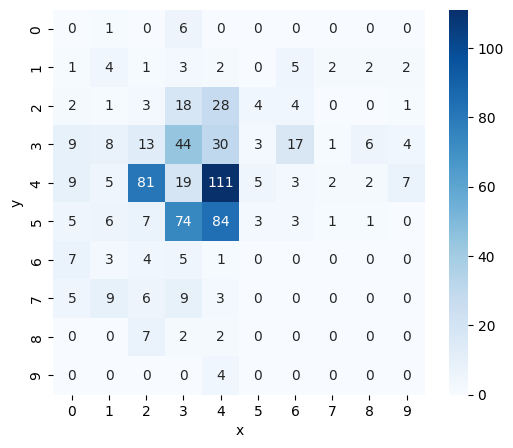

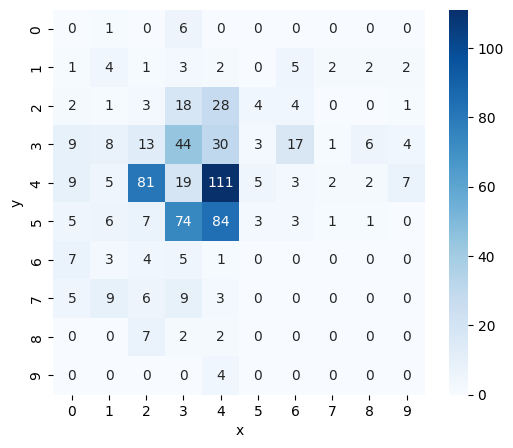

In [ ]:
xy_plt_2d(df_st["farmer_x_y"])
xy_plt_2d(df_be["farmer_x_y"])

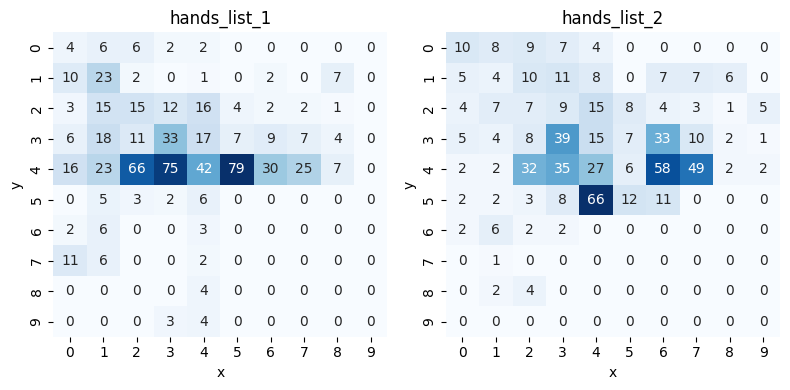

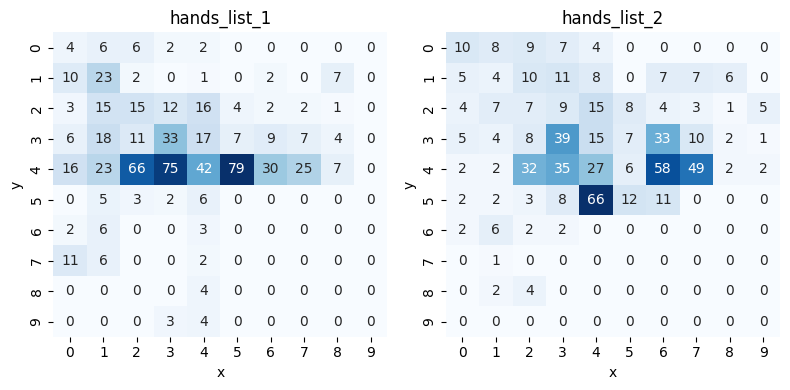

In [ ]:
xy_plt_2d_all(df_st, ["hands_list_1", "hands_list_2"], 1, 2)
xy_plt_2d_all(df_be, ["hands_list_1", "hands_list_2"], 1, 2)

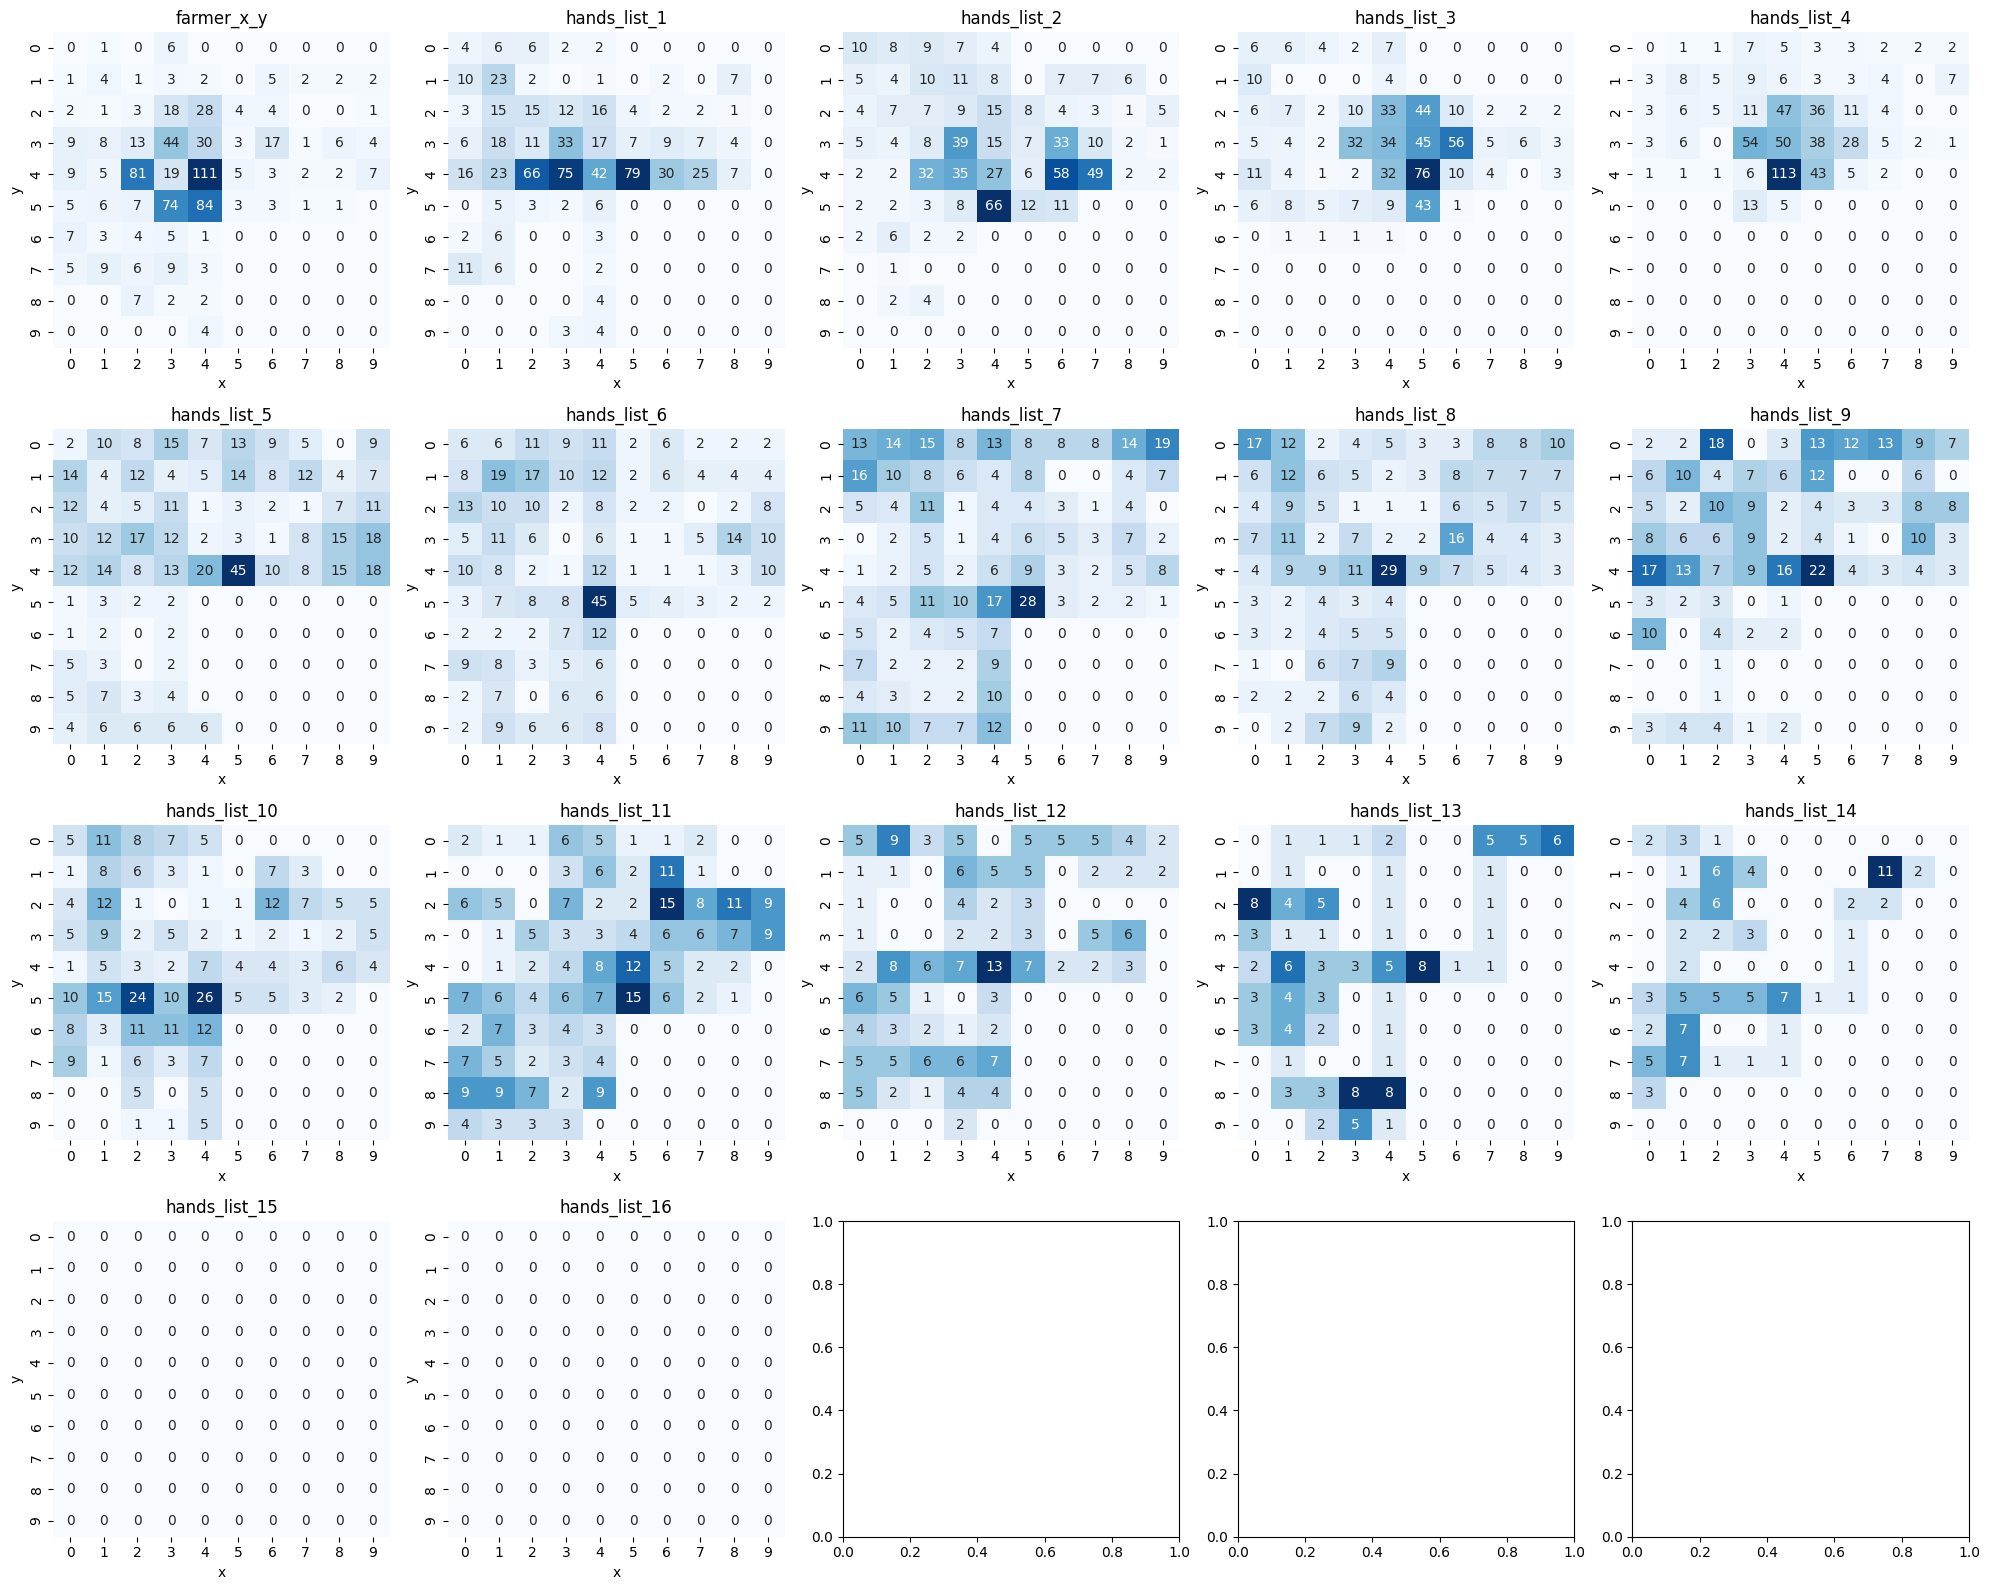

In [ ]:
cols_st = ["farmer_x_y"] + [f"hands_list_{i}" for i in range(1, 17)]
xy_plt_2d_all(df_st, cols_st, 4, 5)

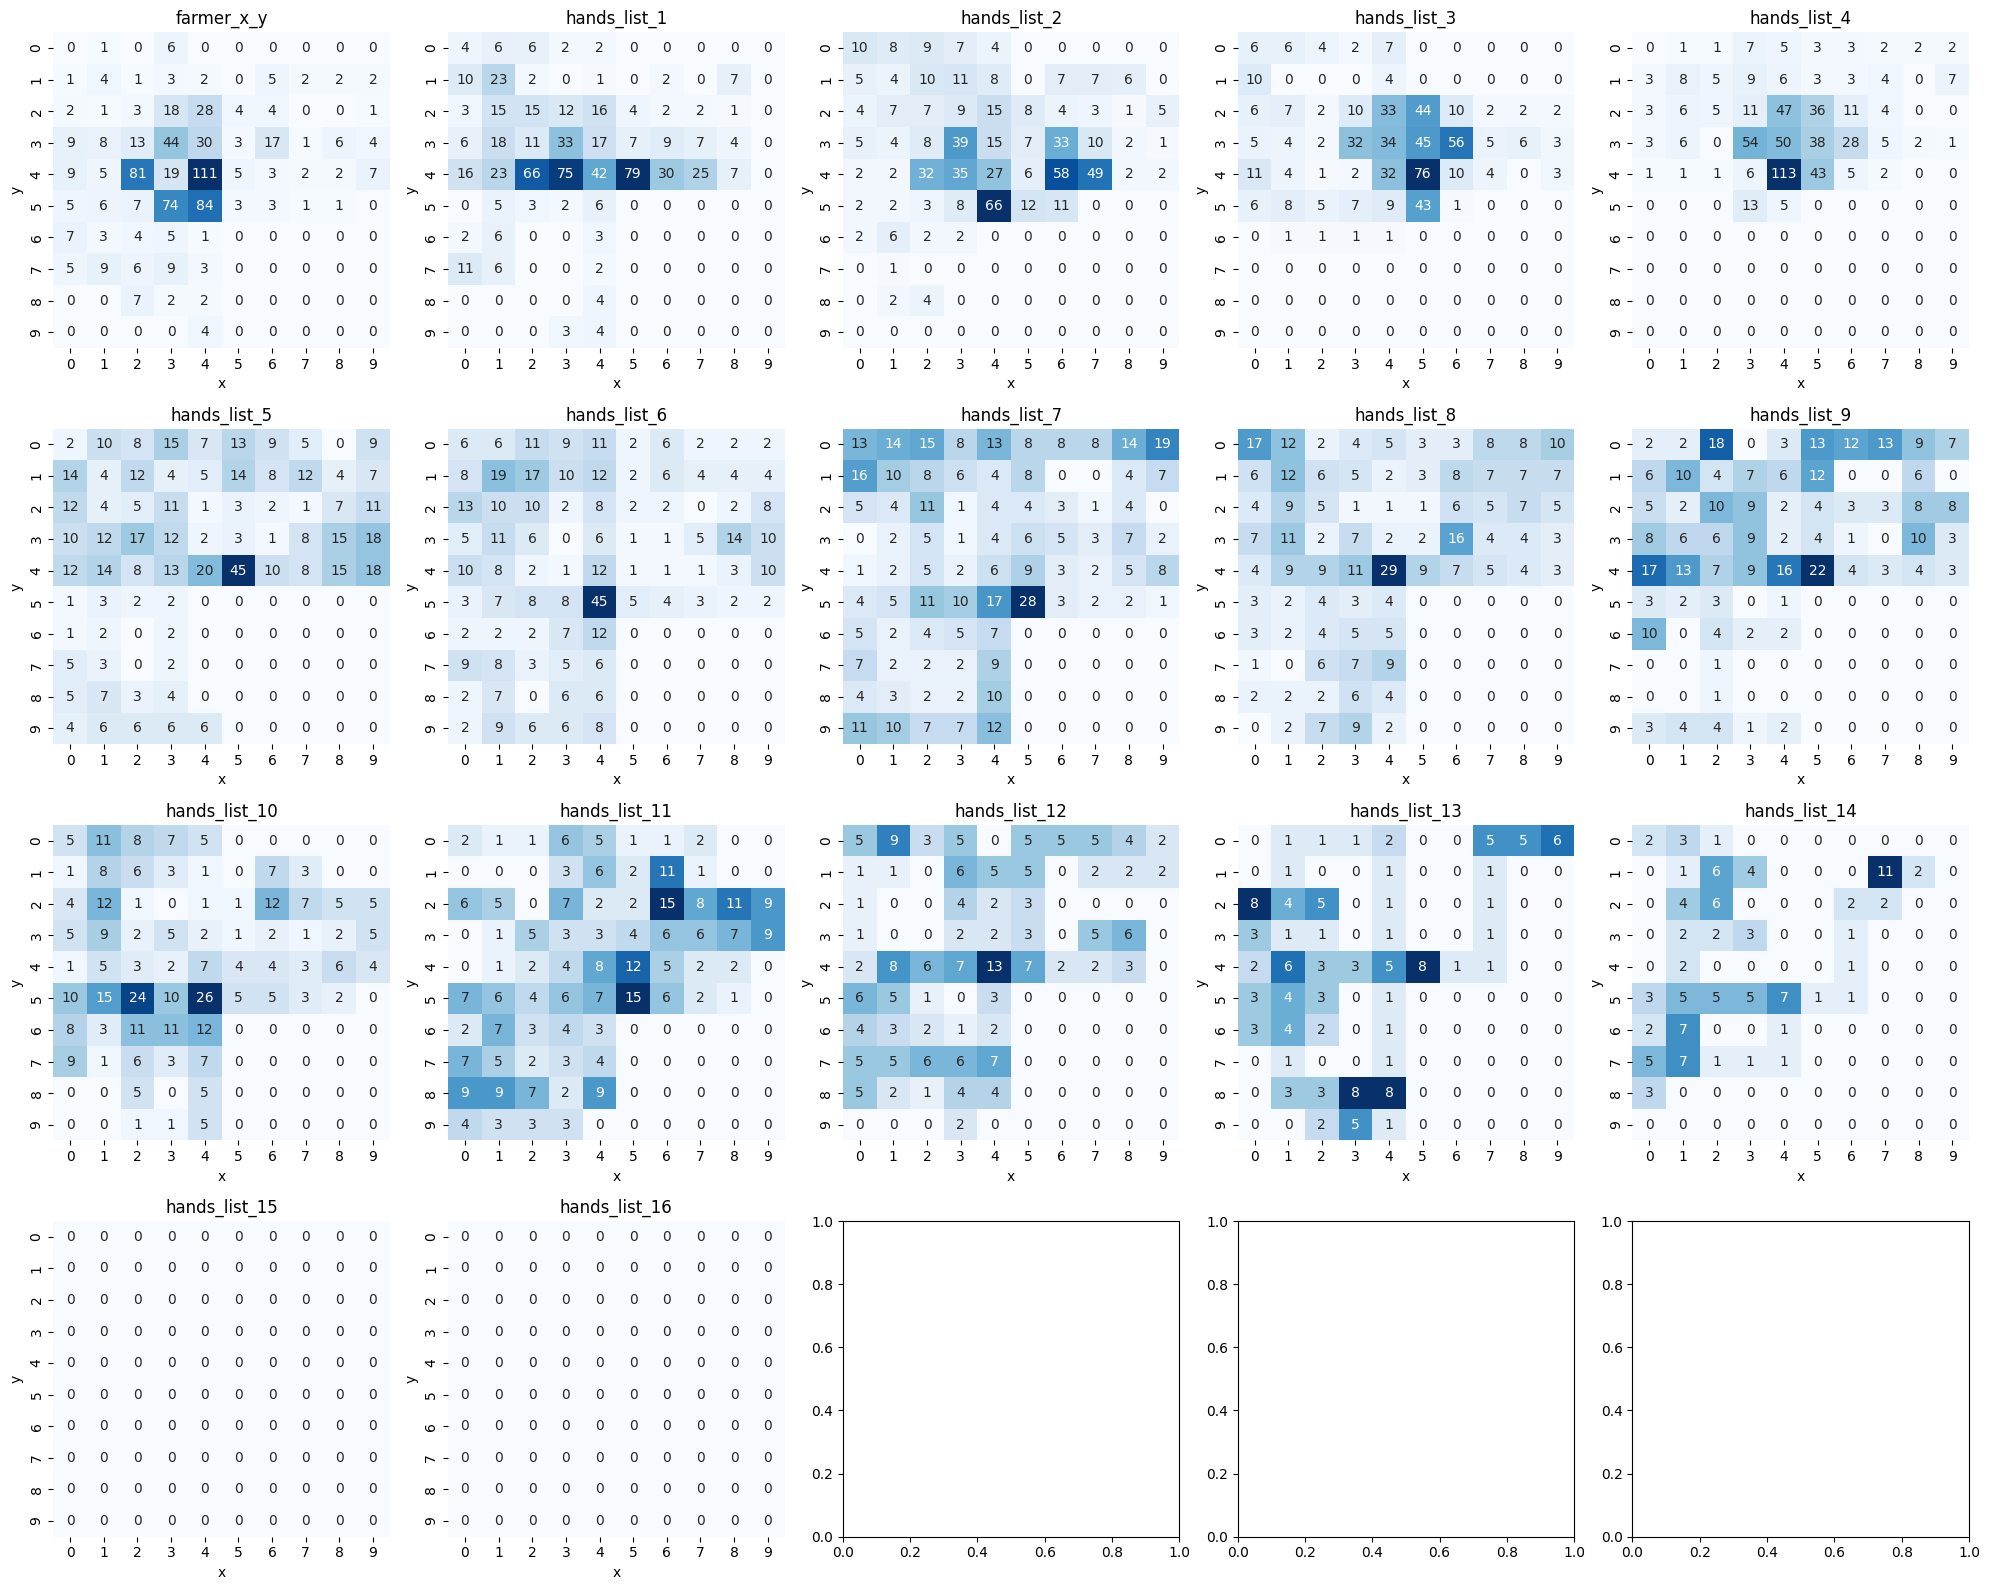

In [ ]:
cols_be = ["farmer_x_y"] + [f"hands_list_{i}" for i in range(1, 17)]
xy_plt_2d_all(df_be, cols_be, 4, 5)

## 従業員達の総合的な動き

* 中心に近いマスであればあるほど値が大きいことに気が付きました。

In [ ]:
df_st = create_all_hands_feature(df_st)
df_be = create_all_hands_feature(df_be)
df_st["all_hands"][0]

[[None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None]]

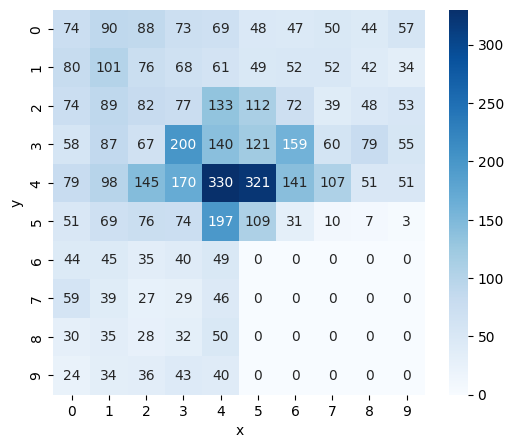

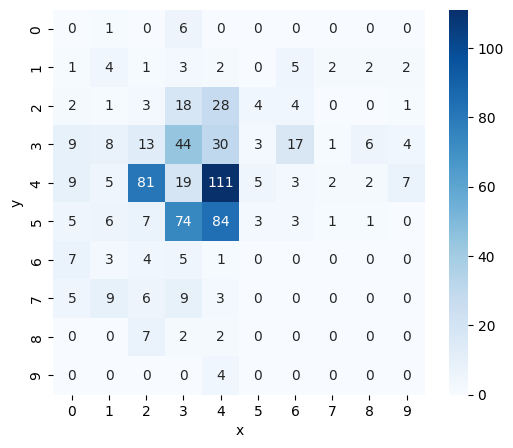

In [ ]:
new_xy_plt_2d(df_st["all_hands"])
xy_plt_2d(df_st["farmer_x_y"])

# 2.土地をアンロックしたタイミング（２データ共通）

* ２つのデータを比較して結果
  全く同じデータだということがわかりました。

In [ ]:
test1 = df_st["unlocked_quadrants"].equals(df_be["unlocked_quadrants"])
test2 = df_st["money"].equals(df_be["money"])

print(f"df_st[farmer_x_y]とdf_be[farmer_x_y]のデータは完全に同じか？: {test1}")
print(f"df_st[money]とdf_be[money]のデータは完全に同じか？: {test2}")

df_st[farmer_x_y]とdf_be[farmer_x_y]のデータは完全に同じか？: True
df_st[money]とdf_be[money]のデータは完全に同じか？: False


In [ ]:
df_st["unlocked_quadrants"].value_counts()

,count
unlocked_quadrants,
"[NW, NE, SW]",455
[NW],169
"[NW, NE]",96


In [ ]:
df_be["unlocked_quadrants"].value_counts()

,count
unlocked_quadrants,
"[NW, NE, SW]",455
[NW],169
"[NW, NE]",96


最適な同じノートブック、ロジックをみんなで共有している可能性

## 可視化するヒストグラム
* 土地をアンロックしたタイミング
* これらも全て同じ動き
* 動きについては最適な動きであり、皆がこの動きに終点したのか？

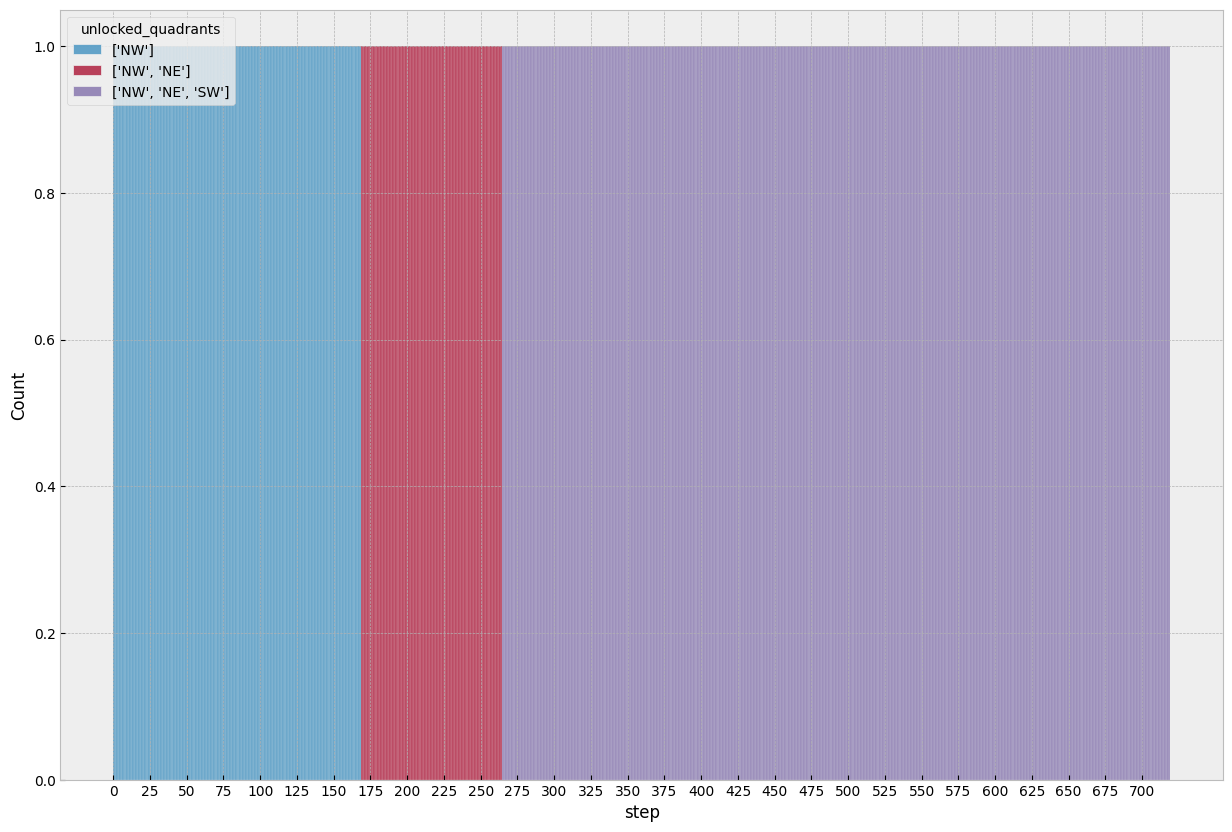

In [ ]:
df_st_unlock = df_st[["step", "unlocked_quadrants"]].copy()
df_st_unlock["unlocked_quadrants"] = df_st_unlock["unlocked_quadrants"].astype(str)
sns_Hist(data=df_st_unlock, x="step", hue="unlocked_quadrants", figsize=(15,10), step=25, bins=720)

## この章で理解した事

* 主はほとんど動いていない、常に[4, 4]の近くにいる。
* そしてそれぞれに役割のポジションがある。



## メモ


#### [jp_readme.md](https://github.com/kenkenkengo0421/Kaggriculture/blob/main/data/jp_readme.md)←ルールブック参照元

1. マップの中心部付近[4, 4]で出来る事

* 物置（Shed）の利用: $[4, 4]$ 自体が物置の設置場所です。直交隣接または同じマスにいることで、アイテムの取り出し（PICKUP）、投入・移動（DROP / PLACE）ができます。

* スポーン（出現）: 農家および雇われた労働者は、毎日の開始時に物置の場所（またはその隣接マス）からスポーンします。

* 一日の終わりの自動納品: 一日の終わりに、農家や労働者がインベントリに保持しているアイテムは自動的に物置へ移動されます（100個の容量オーバー分は破棄）。

2. 農家 "farmer" にしかできないことはない

3. 売買はどこでもできる

# 3.停滞エリアで起きている事

* その場所でなにが行われているか？

#### 特徴量

`["farmer_x_y"]` 農家の座標<br>
`["farmer_action"]`農家の行動<br><br>

`["hands_list_1"]` 労働者1座標<br>
.<br>
.<br>
`["hands_list_20"]` 労働者20座標<br>

`["hands_action_list_1"]` 労働者1行動<br>
.<br>
.<br>
`["hands_action_list_20"]` 労働者20行動<br>



#### グラフ

* 2Dヒートマップ (2D Heatmap)
* ヒストグラム


In [ ]:
#1
def workers_action(df):
    """
    df作成

    """
    base_cols = ["step", "farmer_x_y", "farmer_action"]
    hands_list_cols = [f"hands_list_{i}" for i in range(1, 15)]
    hands_action_cols = [f"hands_action_list_{i}" for i in range(1, 15)]



    return df[["money"] + base_cols + hands_list_cols + hands_action_cols].copy()

#2
def workers_count_list (df):
    """
    df全員分の行動を出力する
    """
    print(df_be_action["farmer_action"].value_counts())
    for i in range(1, 15):
        col_name = f"hands_action_list_{i}"
        if col_name in df.columns:
            print(f"--- {col_name}  ---")
            print(df[col_name].value_counts())
            print()

#4
def my_action_2d_plt(df_xy, df_action, target_action, figsize=(6, 5)):
    """
    特定のアクションが実行された座標をヒートマップに変換：単体

    <df_xy>: 2D配列のSeries (例: df["farmer_x_y"])
    <df_action>: アクションのSeries (例: df["farmer_action"])
    <target_action>: 可視化したいアクションの文字列 (例: "WATER" や "FEED, WHEAT")
    <figsize>: グラフのサイズ設定
    """
    df = pd.DataFrame({
        "x_y": df_xy,
        "action": df_action
    })

    df_filtered = df[df["action"].astype(str).str.contains(target_action, na=False, regex=False)]

    df_filtered_xy = df_filtered["x_y"].apply(convert)
    df_plot = pd.DataFrame(df_filtered_xy.tolist(), columns=["x", "y"])
    df_plot = df_plot.dropna().astype(int)

    heatmap_data = pd.crosstab(df_plot['y'], df_plot['x'])

    grid_range = list(range(10))
    heatmap_data = heatmap_data.reindex(
        index=grid_range, columns=grid_range, fill_value=0
    )

    plt.figure(figsize=figsize)
    sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Action: {target_action}")
    plt.show()
#5
def my_action_2d_plt_all(df_xy, df_action, target_actions, n_rows, n_cols):
    """
    複数のアクションをそれぞれのヒートマップに変換し、一気に描画する

    <df_xy>: 2D配列のSeries (例: df["farmer_x_y"])
    <df_action>: アクションのSeries (例: df["farmer_action"])
    <target_actions>: 可視化したいアクションのリスト (例: ["PLANT", "WATER", "HARVEST"])
    <n_rows>: 行の数
    <n_cols>: 列の数
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))

    if n_rows * n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    grid_range = list(range(10))

    df = pd.DataFrame({
        "x_y": df_xy,
        "action": df_action
    })

    for i, action_str in enumerate(target_actions):
        ax = axes[i]

        df_filtered = df[df["action"].astype(str).str.contains(action_str, na=False, regex=False)]

        df_filtered_xy = df_filtered["x_y"].apply(convert)
        df_plot = pd.DataFrame(df_filtered_xy.tolist(), columns=["x", "y"])
        df_plot = df_plot.dropna().astype(int)

        if not df_plot.empty:
            heatmap_data = pd.crosstab(df_plot['y'], df_plot['x'])
            heatmap_data = heatmap_data.reindex(
                index=grid_range, columns=grid_range, fill_value=0
            )
        else:
            heatmap_data = pd.DataFrame(0, index=grid_range, columns=grid_range)
        ax.grid(False)
        sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d", ax=ax, cbar=False)
        ax.set_title(f"Action: {action_str}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


df_st_action = workers_action(df_st)
df_be_action = workers_action(df_be)

In [ ]:
df_st_action

,money,step,farmer_x_y,farmer_action,hands_list_1,hands_list_2,hands_list_3,hands_list_4,hands_list_5,hands_list_6,...,hands_action_list_5,hands_action_list_6,hands_action_list_7,hands_action_list_8,hands_action_list_9,hands_action_list_10,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14
0,3000.0,0,"[4, 4]",[PASS],"[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[None, None]",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,22.0,1,"[4, 4]",[PASS],"[5, 4]","[4, 5]","[5, 5]","[4, 4]","[5, 4]","[None, None]",...,[PASS],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,50.0,2,"[4, 4]","[PICKUP, SHEEP, 1]","[4, 4]","[4, 4]","[4, 5]","[3, 4]","[4, 4]","[None, None]",...,[WEST],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,22.0,3,"[4, 4]","[PICKUP, WHEAT, 1]","[4, 4]","[4, 4]","[3, 5]","[2, 4]","[3, 4]","[None, None]",...,[WEST],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,50.0,4,"[3, 4]",[WEST],"[4, 4]","[3, 4]","[2, 5]","[1, 4]","[2, 4]","[None, None]",...,[WEST],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,144726.0,715,"[5, 4]",[DROP],"[4, 6]","[4, 3]","[4, 5]","[5, 3]","[5, 2]","[4, 5]",...,[SOUTH],[DROP],[SOUTH],[SOUTH],[EAST],[SOUTH],[SOUTH],[None],[None],[None]
716,146959.0,716,"[5, 4]",[COLLECT_FERTILIZER],"[4, 5]","[4, 4]","[4, 5]","[5, 4]","[5, 3]","[3, 5]",...,[SOUTH],[WEST],[SOUTH],[DROP],[DROP],[SOUTH],[SOUTH],[None],[None],[None]
717,156142.0,717,"[4, 4]",[WEST],"[4, 5]","[4, 4]","[3, 5]","[5, 4]","[5, 4]","[3, 6]",...,[SOUTH],[SOUTH],[SOUTH],[EAST],[PASS],[SOUTH],[SOUTH],[None],[None],[None]
718,157185.0,718,"[4, 4]",[COLLECT_FERTILIZER],"[4, 5]","[4, 4]","[2, 5]","[6, 4]","[5, 4]","[3, 7]",...,[DROP],[SOUTH],[SOUTH],[EAST],[PASS],[DROP],[SOUTH],[None],[None],[None]


In [ ]:
df_be_action

,money,step,farmer_x_y,farmer_action,hands_list_1,hands_list_2,hands_list_3,hands_list_4,hands_list_5,hands_list_6,...,hands_action_list_5,hands_action_list_6,hands_action_list_7,hands_action_list_8,hands_action_list_9,hands_action_list_10,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14
0,3000.0,0,"[4, 4]",[PASS],"[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[None, None]",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,22.0,1,"[4, 4]",[PASS],"[5, 4]","[4, 5]","[5, 5]","[4, 4]","[5, 4]","[None, None]",...,[PASS],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,50.0,2,"[4, 4]","[PICKUP, SHEEP, 1]","[4, 4]","[4, 4]","[4, 5]","[3, 4]","[4, 4]","[None, None]",...,[WEST],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,22.0,3,"[4, 4]","[PICKUP, WHEAT, 1]","[4, 4]","[4, 4]","[3, 5]","[2, 4]","[3, 4]","[None, None]",...,[WEST],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,50.0,4,"[3, 4]",[WEST],"[4, 4]","[3, 4]","[2, 5]","[1, 4]","[2, 4]","[None, None]",...,[WEST],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,91747.0,715,"[5, 4]",[DROP],"[4, 6]","[4, 3]","[4, 5]","[5, 3]","[5, 2]","[4, 5]",...,[SOUTH],[DROP],[SOUTH],[SOUTH],[EAST],[SOUTH],[SOUTH],[None],[None],[None]
716,93457.0,716,"[5, 4]",[COLLECT_FERTILIZER],"[4, 5]","[4, 4]","[4, 5]","[5, 4]","[5, 3]","[3, 5]",...,[SOUTH],[WEST],[SOUTH],[DROP],[DROP],[SOUTH],[SOUTH],[None],[None],[None]
717,98093.0,717,"[4, 4]",[WEST],"[4, 5]","[4, 4]","[3, 5]","[5, 4]","[5, 4]","[3, 6]",...,[SOUTH],[SOUTH],[SOUTH],[EAST],[PASS],[SOUTH],[SOUTH],[None],[None],[None]
718,99229.0,718,"[4, 4]",[COLLECT_FERTILIZER],"[4, 5]","[4, 4]","[2, 5]","[6, 4]","[5, 4]","[3, 7]",...,[DROP],[SOUTH],[SOUTH],[EAST],[PASS],[DROP],[SOUTH],[None],[None],[None]


In [ ]:
df_st_action.columns, df_be_action.columns

(Index(['money', 'step', 'farmer_x_y', 'farmer_action', 'hands_list_1',
        'hands_list_2', 'hands_list_3', 'hands_list_4', 'hands_list_5',
        'hands_list_6', 'hands_list_7', 'hands_list_8', 'hands_list_9',
        'hands_list_10', 'hands_list_11', 'hands_list_12', 'hands_list_13',
        'hands_list_14', 'hands_action_list_1', 'hands_action_list_2',
        'hands_action_list_3', 'hands_action_list_4', 'hands_action_list_5',
        'hands_action_list_6', 'hands_action_list_7', 'hands_action_list_8',
        'hands_action_list_9', 'hands_action_list_10', 'hands_action_list_11',
        'hands_action_list_12', 'hands_action_list_13', 'hands_action_list_14'],
       dtype='object'),
 Index(['money', 'step', 'farmer_x_y', 'farmer_action', 'hands_list_1',
        'hands_list_2', 'hands_list_3', 'hands_list_4', 'hands_list_5',
        'hands_list_6', 'hands_list_7', 'hands_list_8', 'hands_list_9',
        'hands_list_10', 'hands_list_11', 'hands_list_12', 'hands_list_13',
       

In [ ]:
workers_count_list(df_st_action),

farmer_action
[PASS]                  172
[CARE]                   76
[WEST]                   75
[COLLECT_FERTILIZER]     73
[FEED, WHEAT]            67
[NORTH]                  59
[SOUTH]                  55
[WATER]                  51
[EAST]                   38
[PICKUP, WHEAT, 2]       20
[HARVEST]                17
[PICKUP, WHEAT, 4]        6
[PICKUP, WHEAT, 1]        4
[DROP]                    4
[PLACE, SHEEP]            1
[PICKUP, SHEEP, 1]        1
[BUILD_PASTURE]           1
Name: count, dtype: int64
--- hands_action_list_1  ---
hands_action_list_1
[PASS]                  123
[WEST]                  120
[WATER]                  63
[NORTH]                  62
[None]                   53
[CARE]                   53
[FEED, WHEAT]            51
[COLLECT_FERTILIZER]     51
[EAST]                   41
[SOUTH]                  40
[PICKUP, WHEAT, 2]       20
[HARVEST]                19
[PLACE, COW]              5
[DROP]                    5
[BUILD_PASTURE]           3
[PLANT, WHEAT] 

(None,)

In [ ]:
workers_count_list(df_be_action)

farmer_action
[PASS]                  172
[CARE]                   76
[WEST]                   75
[COLLECT_FERTILIZER]     73
[FEED, WHEAT]            67
[NORTH]                  59
[SOUTH]                  55
[WATER]                  51
[EAST]                   38
[PICKUP, WHEAT, 2]       20
[HARVEST]                17
[PICKUP, WHEAT, 4]        6
[PICKUP, WHEAT, 1]        4
[DROP]                    4
[PLACE, SHEEP]            1
[PICKUP, SHEEP, 1]        1
[BUILD_PASTURE]           1
Name: count, dtype: int64
--- hands_action_list_1  ---
hands_action_list_1
[PASS]                  123
[WEST]                  120
[WATER]                  63
[NORTH]                  62
[None]                   53
[CARE]                   53
[FEED, WHEAT]            51
[COLLECT_FERTILIZER]     51
[EAST]                   41
[SOUTH]                  40
[PICKUP, WHEAT, 2]       20
[HARVEST]                19
[PLACE, COW]              5
[DROP]                    5
[BUILD_PASTURE]           3
[PLANT, WHEAT] 

## 少し休憩。。。。☕

pythonとkaggleの同時に学習しているのでかなり疲労しております。<br>
日本の曲です。聴いてみてください。

**[chay/Let It Be / The Beatles【cover by chay】](https://youtu.be/JrT3hpSf4Gk?si=XQ84vgTfP3Z7kl3m) youtubeより。**



## そこで何が行われているかの特徴量の考察
| **アクションカテゴリ** | **実行可能なコマンド**                                                                  | **備考**                                                |
| ------------- | ------------------------------------------------------------------------------ | ------------------------------------------------------------ |
| **移動・運搬**     | `PICKUP`:小屋（Shed）にあるアイテム（動物、肥料、収穫物など）を最大N個、手持ち（インベントリ）に取り出します。種は専用スロットにあるため対象外です<br><br> `DROP`:手持ちのアイテムをマスに置きます。小屋に隣接している場合は小屋の中に格納します。<br><br> `PLACE`:手持ちの動物を対応する空の施設（牧草地など）に配置します。<br><br>                    | |
| **農業（植物）**    | `PLANT`:購入して共有スロットにある「種」を現在のマスに植えます。<br><br> `WATER`:植物に水をやります。1日1回のみ有効です<br><br> `HARVEST`: 成長した植物から農産物を収穫し、手持ちに追加します。<br><br>`FERTILIZE`: 植物に肥料を与えます。その後の3日間、水やり時のボーナス収穫量が倍増します。<br><br>`DIG`: マスに発生した雑草（WEED）を取り除きます。<br><br>                                | |
| **畜産（動物）**    | `BUILD_COOP`: 鳥小屋（Gooseなどの鳥用）を建設します。<br><br>  `BUILD_PASTURE`: 牧草地（牛や羊用）を建設します。<br><br> `FEED`: 手持ちの作物（小麦など）を消費して、動物にエサを与えます（1日1回）<br><br> `COLLECT_FERTILIZER`:動物から排出された肥料（FERTILIZER）を回収します。動物1頭につき1日1つ生成されます。<br><br> `CARE`:動物の世話をします（1日1回）<br><br> |  |
| 市場取引      | `BUY_SEED`:市場から指定した「種」を購入します。<br><br> `BUY_PRODUCT`:市場から農産物や肥料などのアイテムを購入します。<br><br> `BUY_ANIMAL`: 市場から動物を購入します。<br><br>`SELL`: 手持ち、または小屋にあるアイテムを市場に売却します。種は売却できません。<br><br>                                |                        |
| 雇用と拡張     | `HIRE`:その日限定の労働者（Farm hand）を雇います。同日に雇う人数が増えるほど採用コストが上がります。<br><br> `BUY_LAND`: 隣接する新しい5x5の土地（区画）を購入し、農場エリアを拡張します。<br><br>                                                             |                   |

<br><br><br><br>  

ログにあるのは上から３点のようです。
念の為実際に出力してみたが、値はありませんでした。

<br><br>

**従業員の足跡**

In [ ]:
print(df_st_action["farmer_x_y"])

0      [4, 4]
1      [4, 4]
2      [4, 4]
3      [4, 4]
4      [3, 4]
        ...  
715    [5, 4]
716    [5, 4]
717    [4, 4]
718    [4, 4]
719    [4, 4]
Name: farmer_x_y, Length: 720, dtype: object



## 移動・運搬

```
PICKUP:小屋（Shed）にあるアイテム（動物、肥料、収穫物など）を最大N個、手持ち（インベントリ）に取り出します。種は専用スロットにあるため対象外です

DROP:手持ちのアイテムをマスに置きます。小屋に隣接している場合は小屋の中に格納します。

PLACE:手持ちの動物を対応する空の施設（牧草地など）に配置します。
```

* 農家

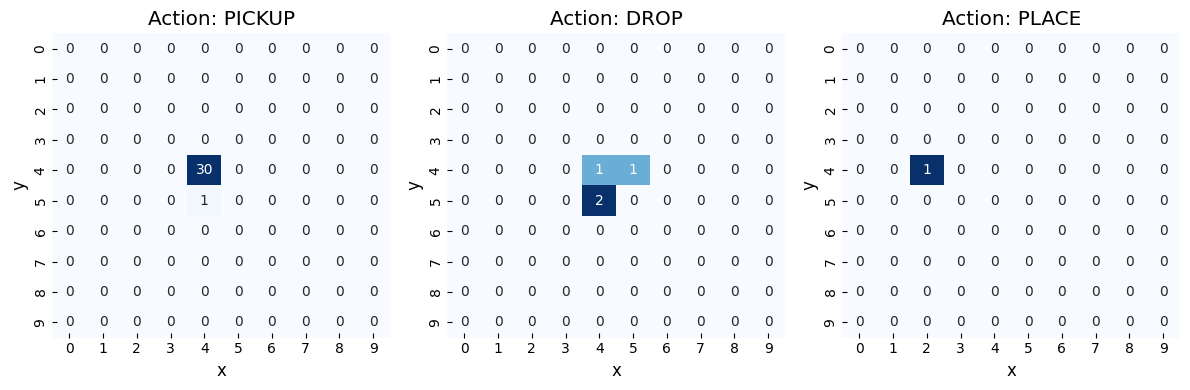

In [ ]:
target_list = ["PICKUP", "DROP", "PLACE"]
my_action_2d_plt_all(df_st_action["farmer_x_y"], df_st_action["farmer_action"], target_list, 1, 3)

* 従業員

従業員1


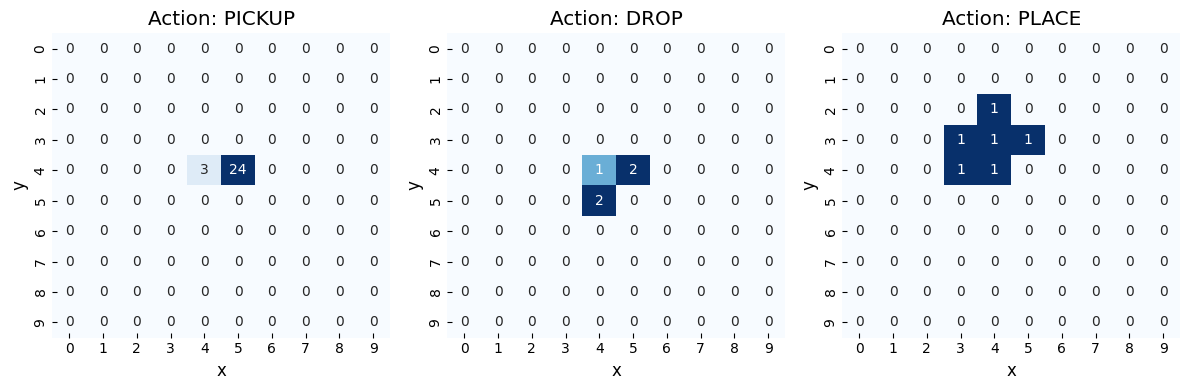

従業員2


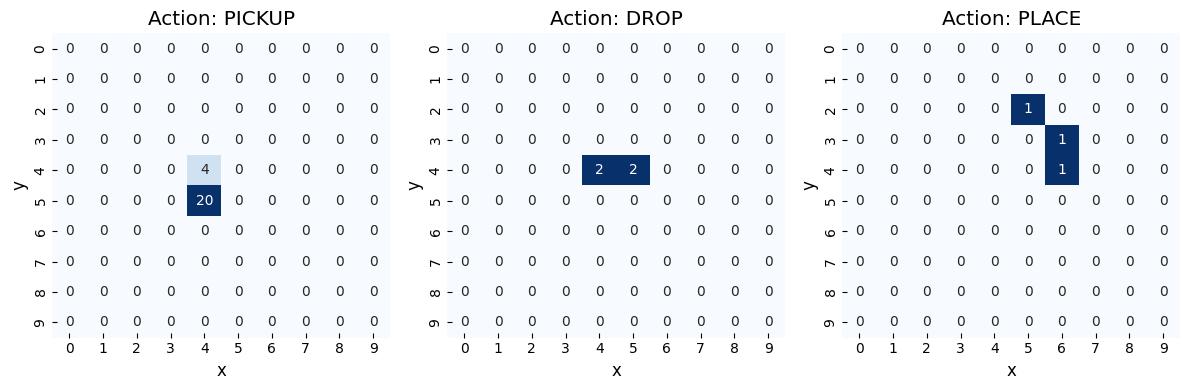

従業員3


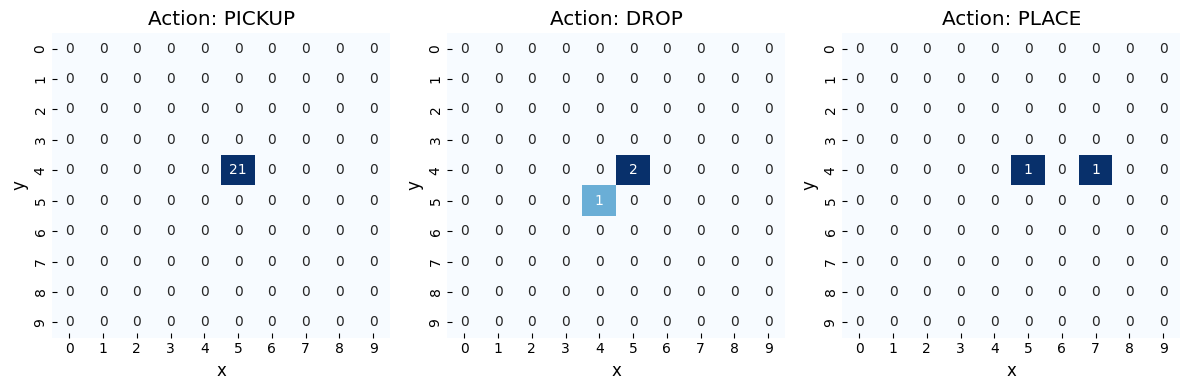

従業員4


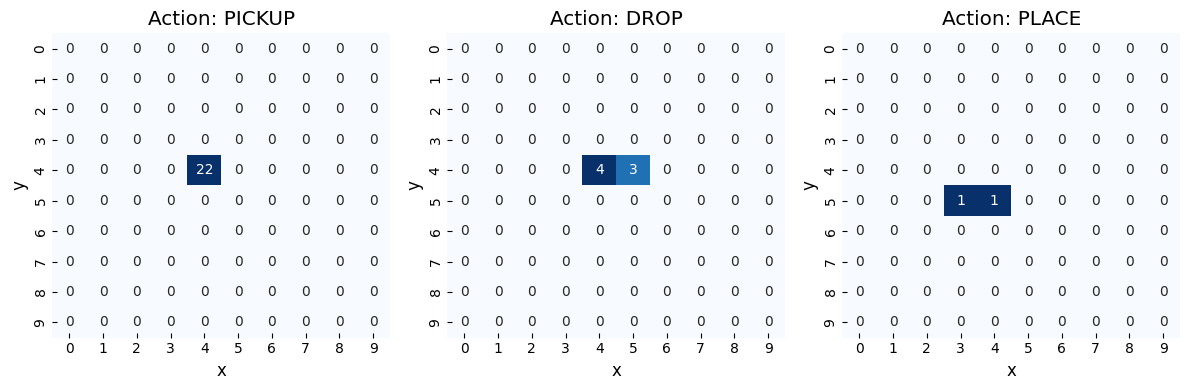

従業員5


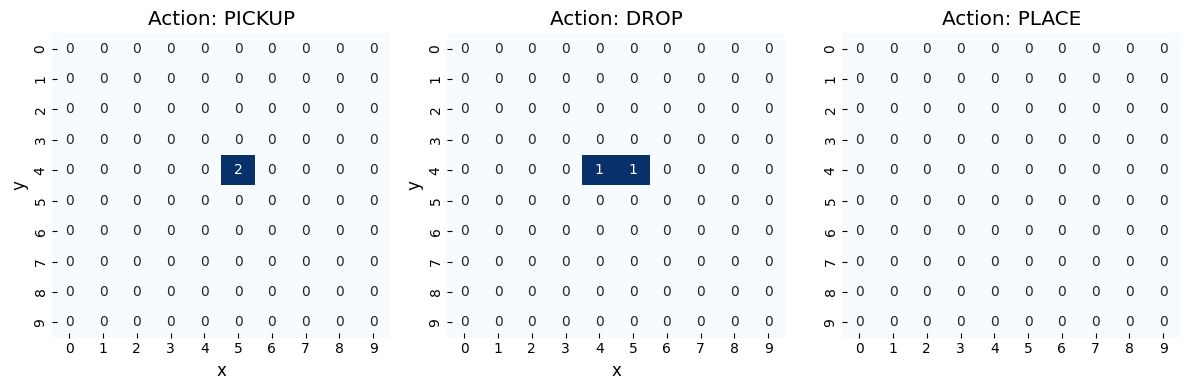

従業員6


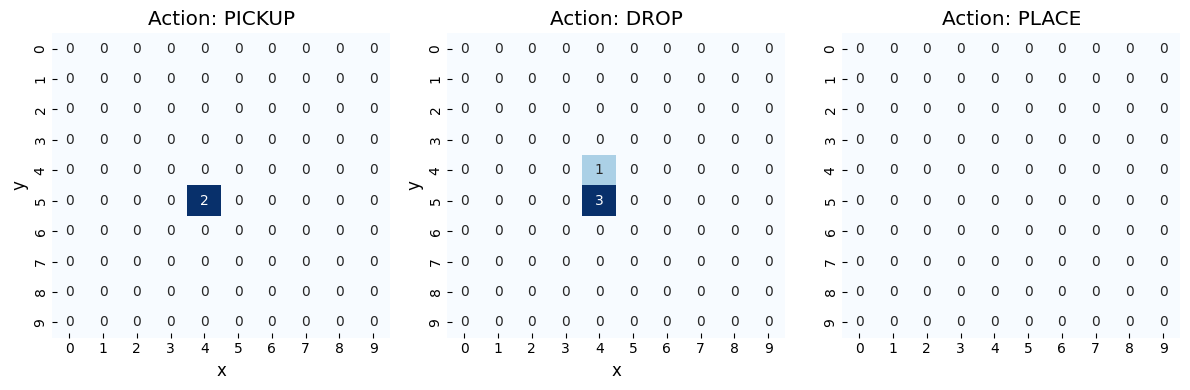

従業員7


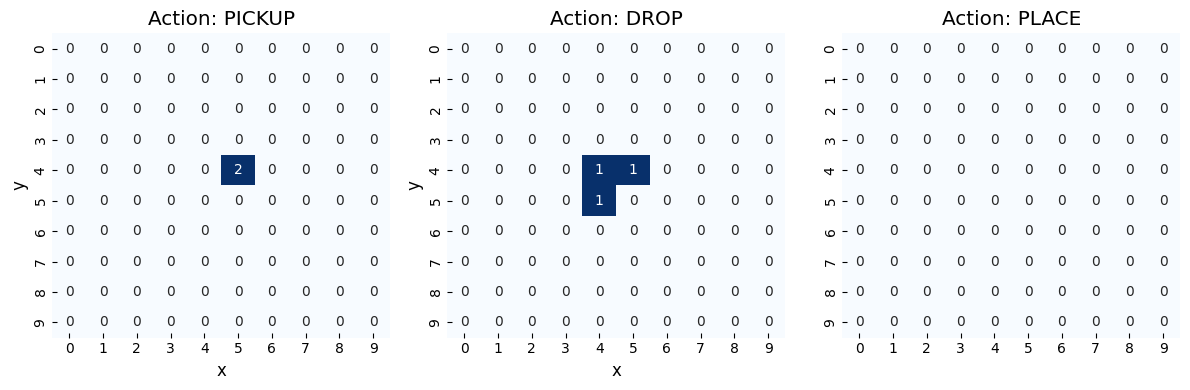

従業員8


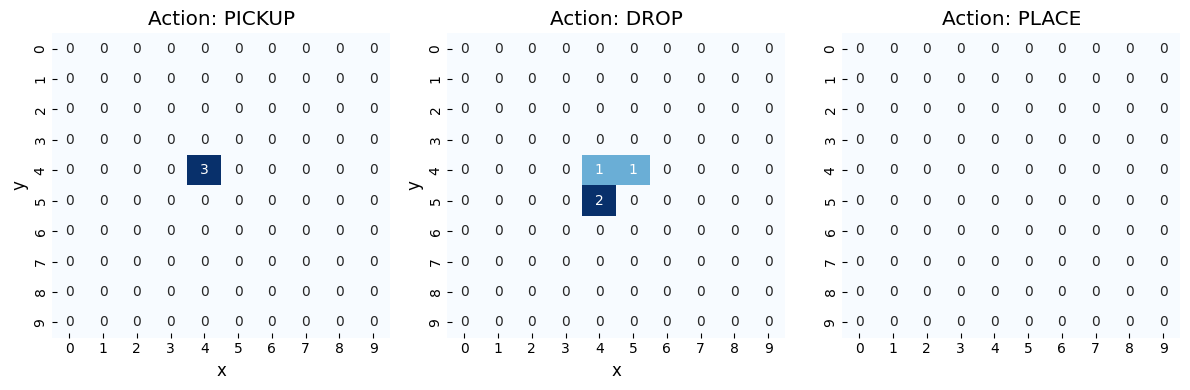

従業員9


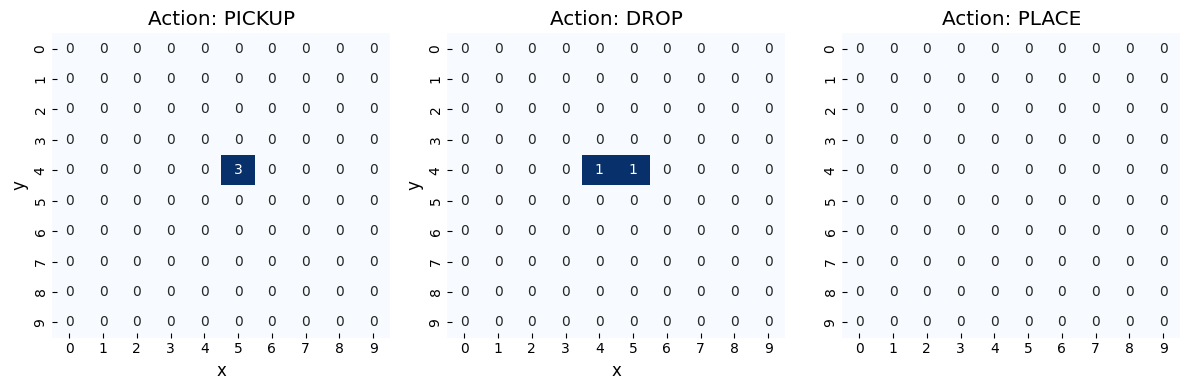

従業員10


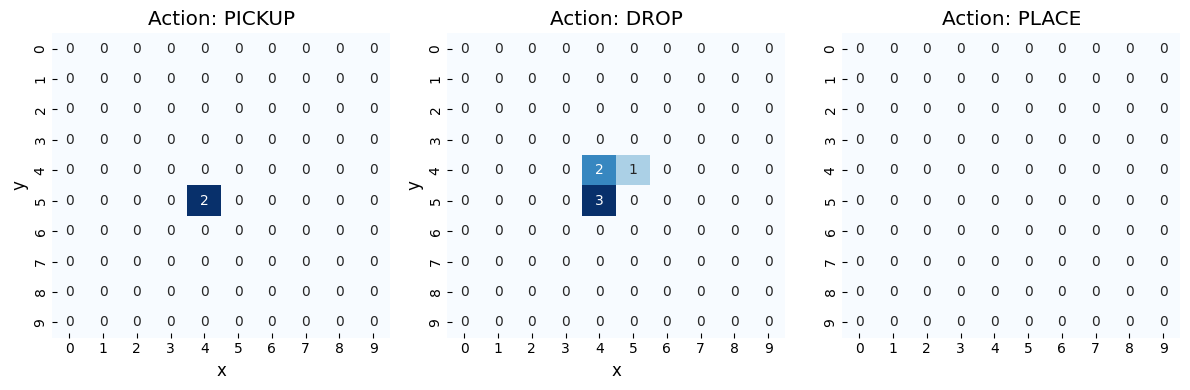

従業員11


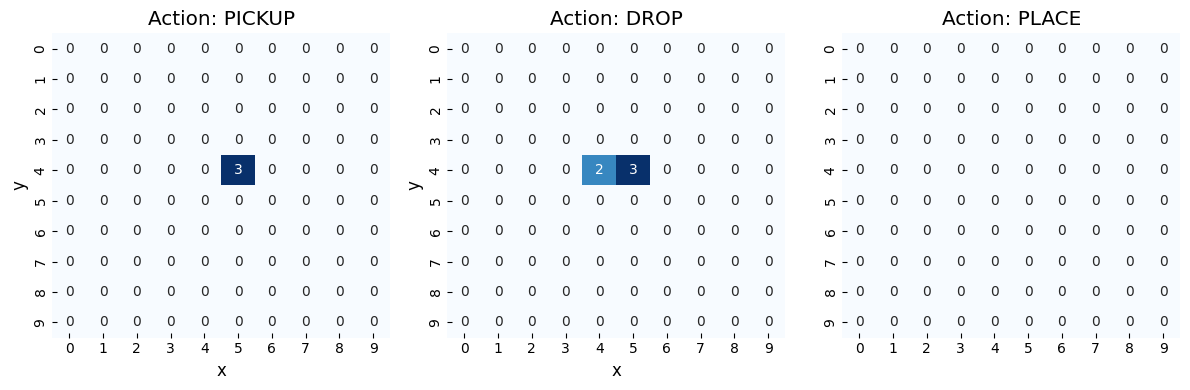

従業員12


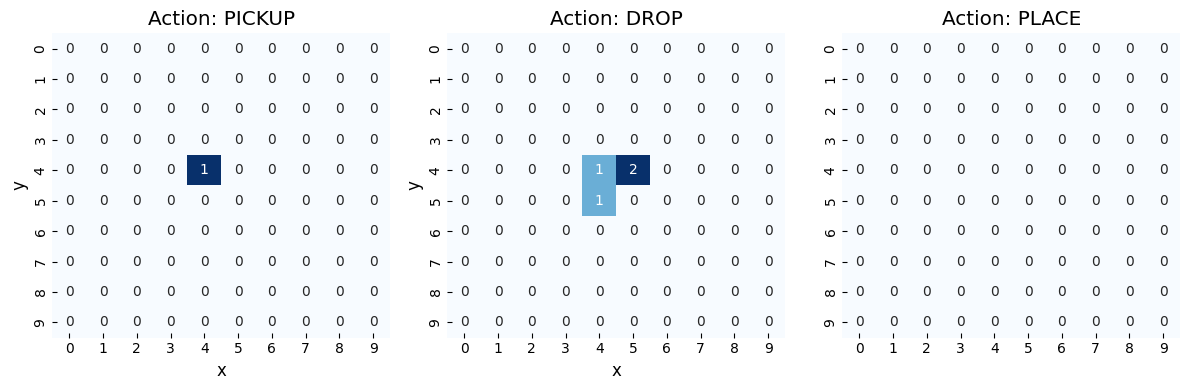

従業員13


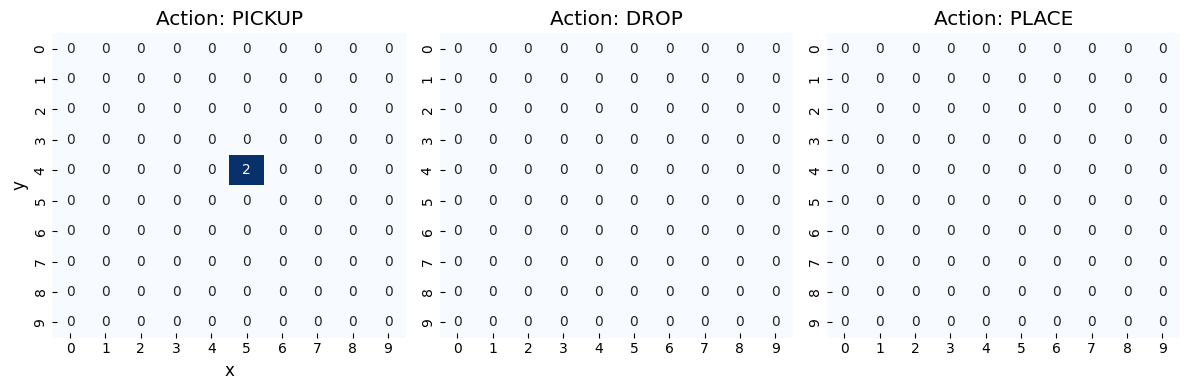

従業員14


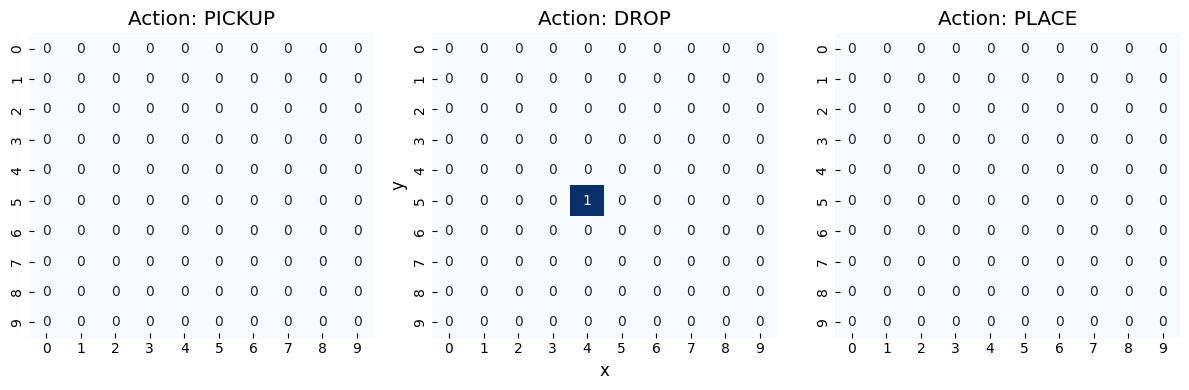

In [ ]:
def ac_move(num):
    print(f"従業員{num}")
    target_list = ["PICKUP", "DROP", "PLACE"]
    my_action_2d_plt_all(df_st[f'hands_list_{num}'], df_st[f'hands_action_list_{num}'], target_list, 1, 3)

for i in range(1, 15):
    ac_move(i)

## 農業（植物）

```
PLANT:購入して共有スロットにある「種」を現在のマスに植えます。

WATER:植物に水をやります。1日1回のみ有効です

HARVEST: 成長した植物から農産物を収穫し、手持ちに追加します。

FERTILIZE: 植物に肥料を与えます。その後の3日間、水やり時のボーナス収穫量が倍増します。

DIG: マスに発生した雑草（WEED）を取り除きます。
```

* 農家

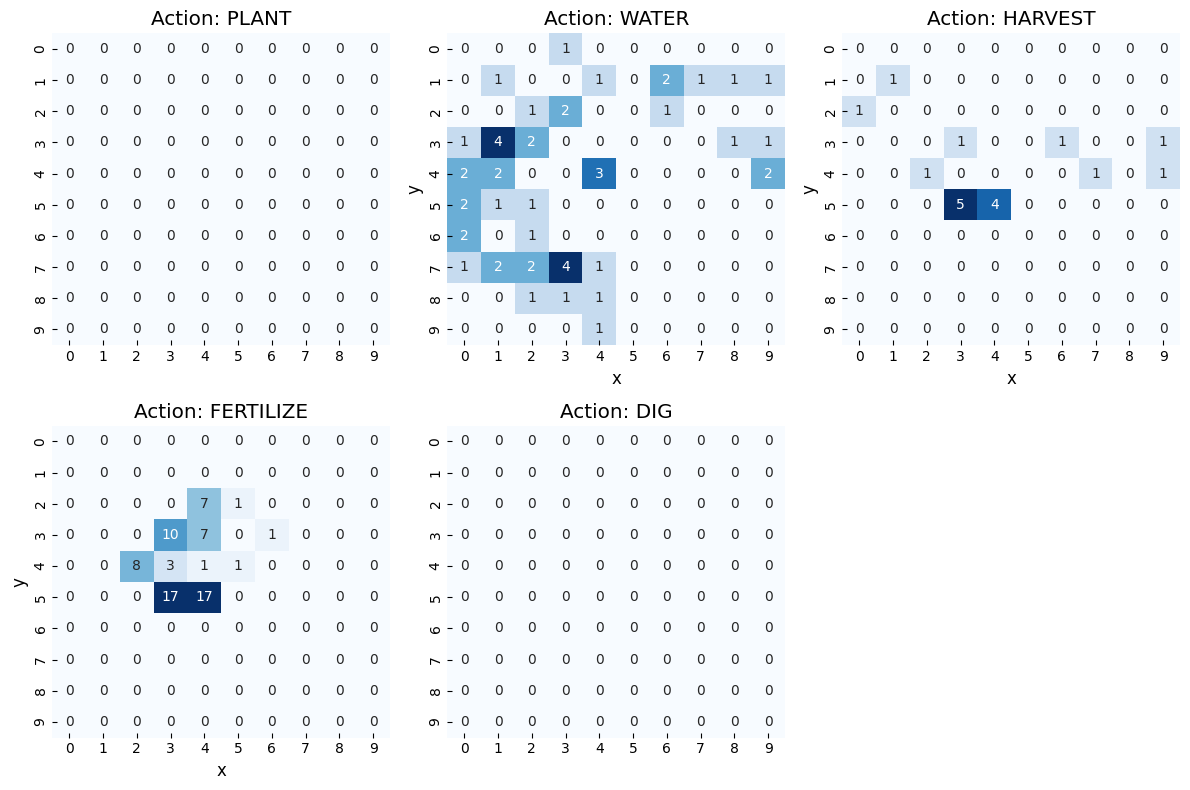

In [ ]:
target_list = ["PLANT", "WATER", "HARVEST","FERTILIZE","DIG" ]
my_action_2d_plt_all(df_st_action["farmer_x_y"], df_st_action["farmer_action"], target_list, 2, 3)

従業員1


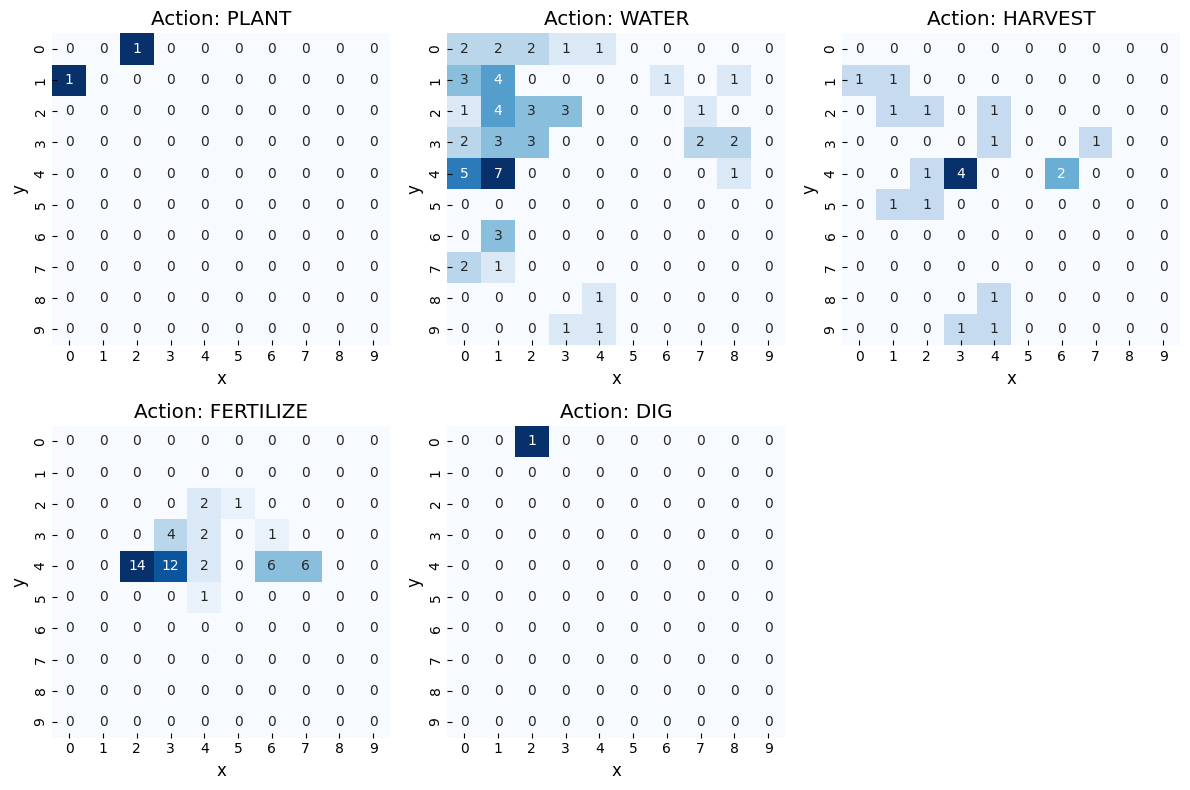

従業員2


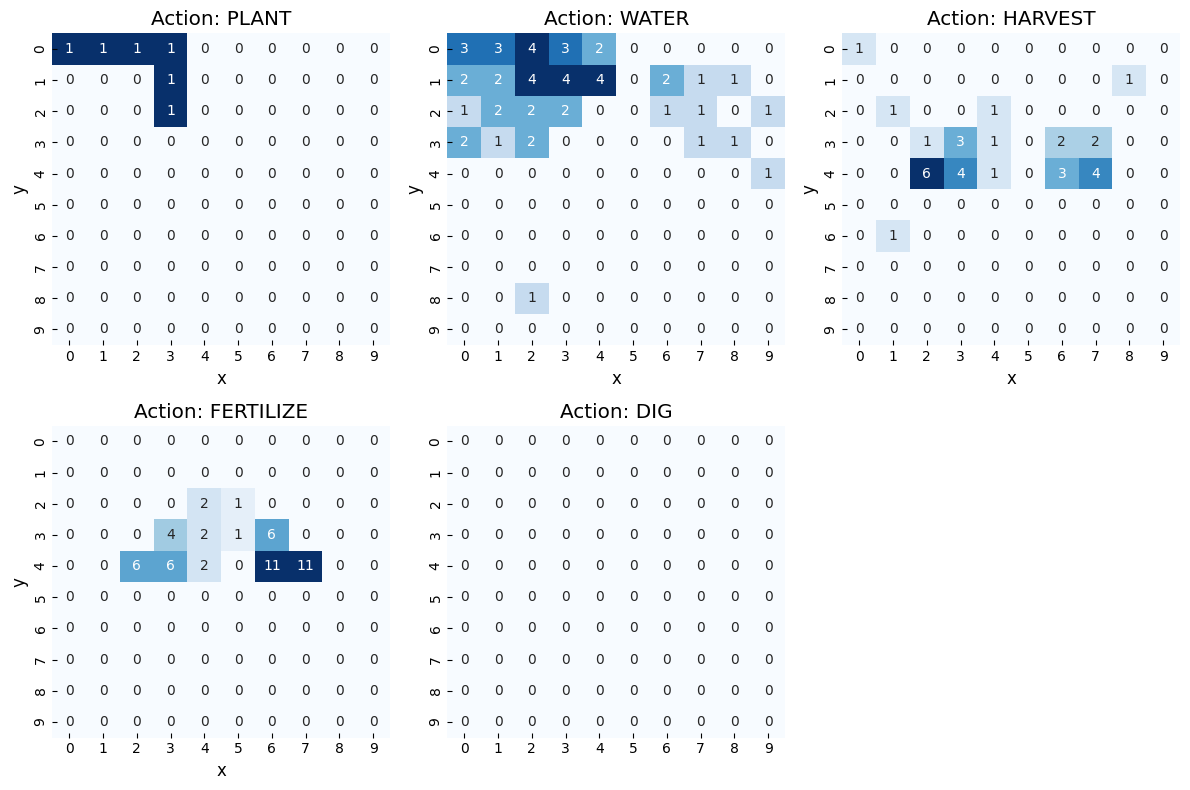

従業員3


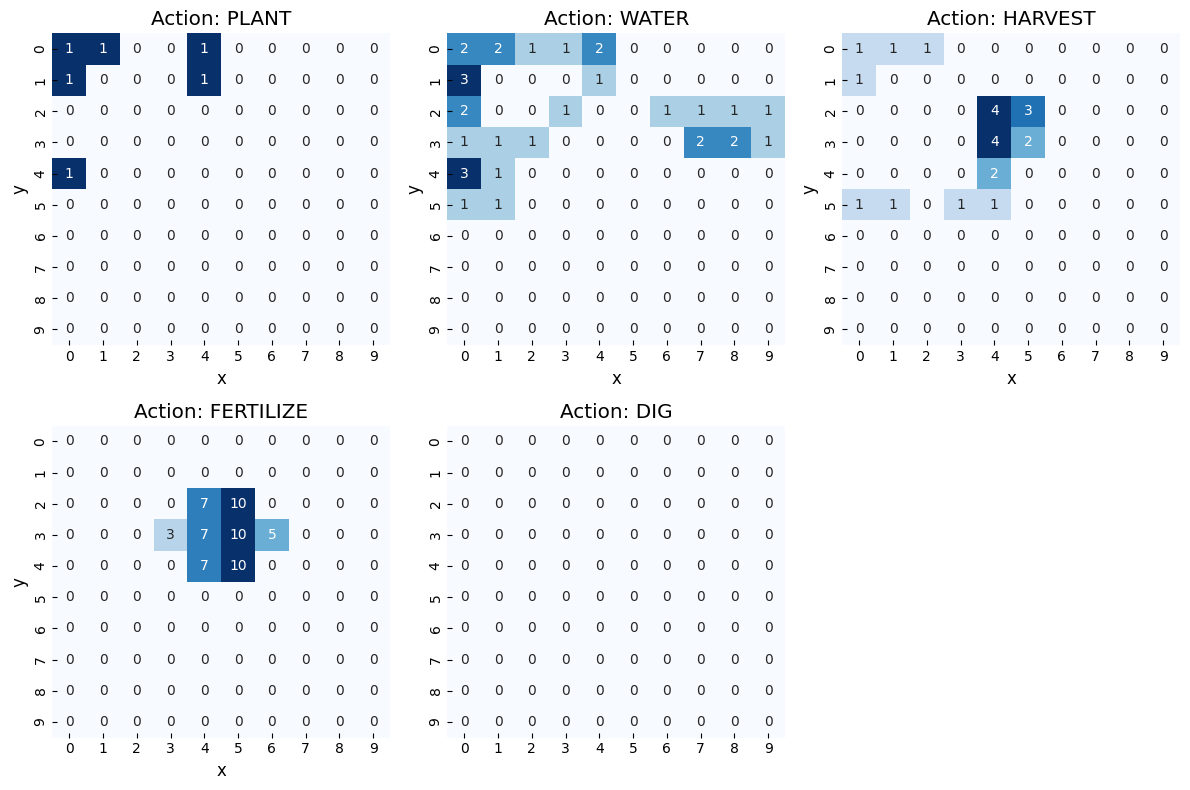

従業員4


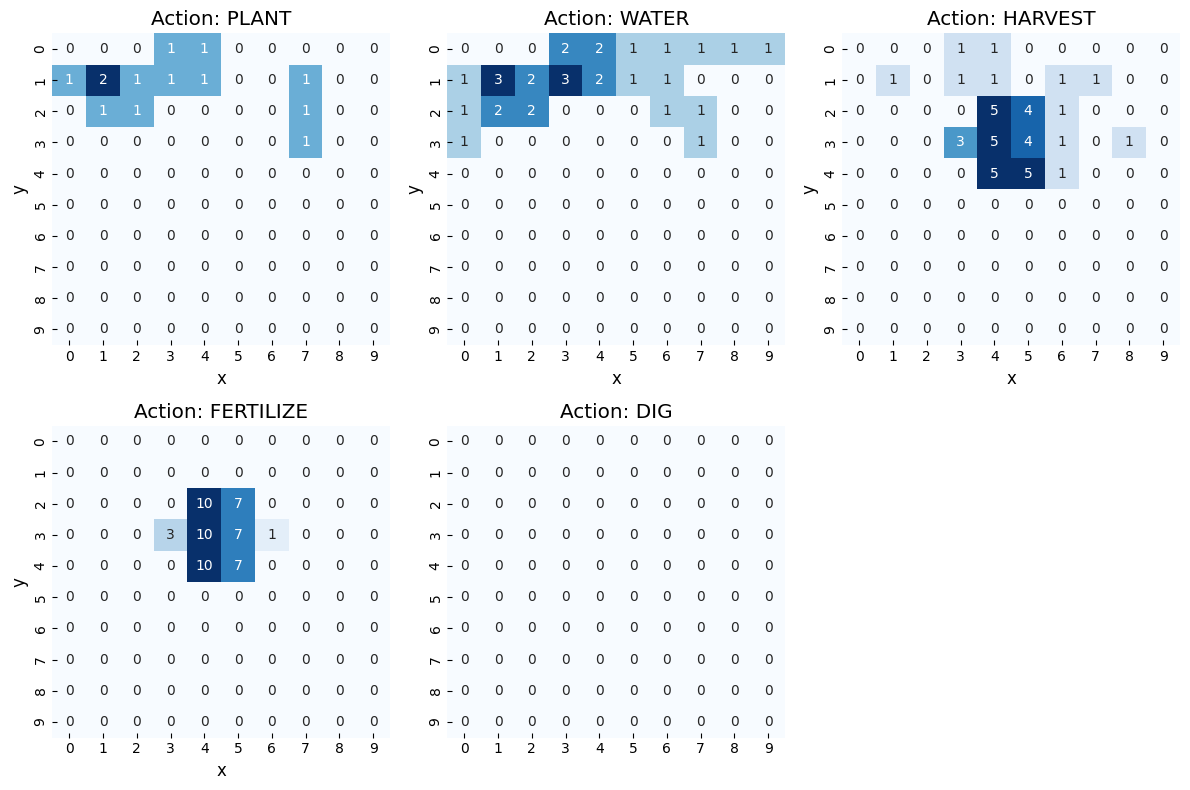

従業員5


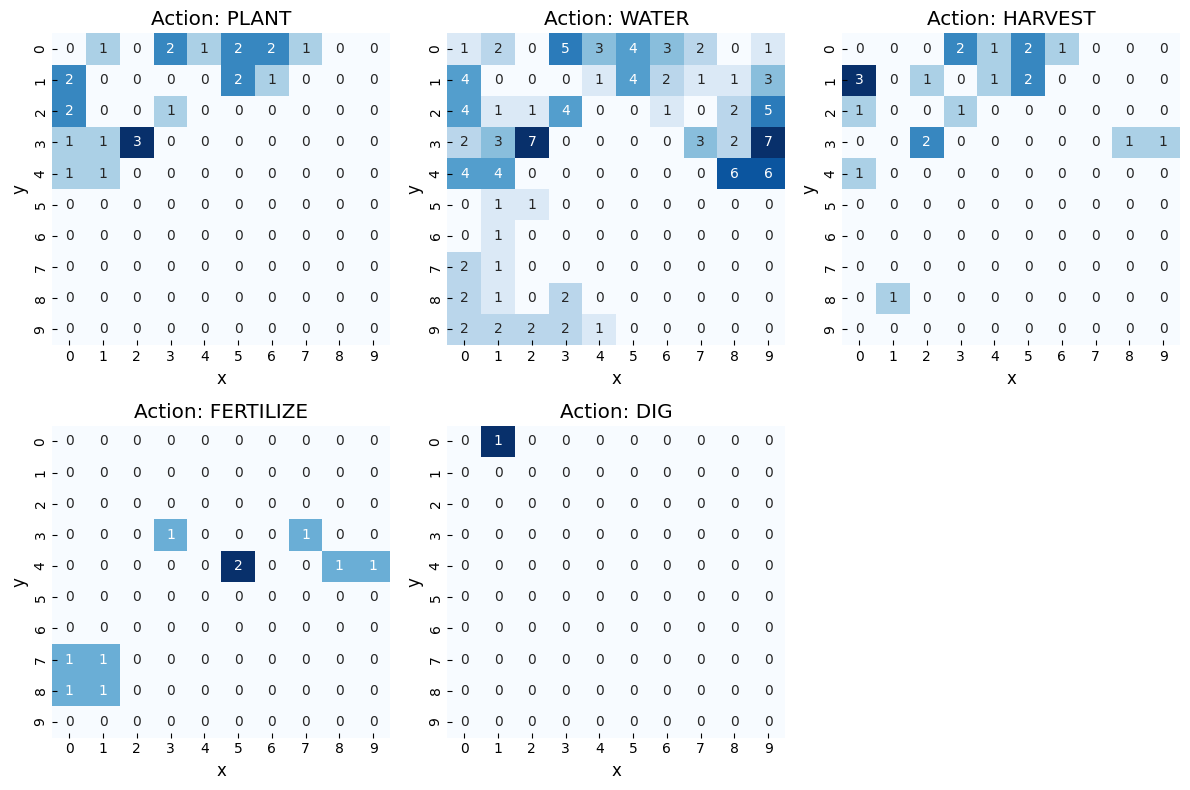

従業員6


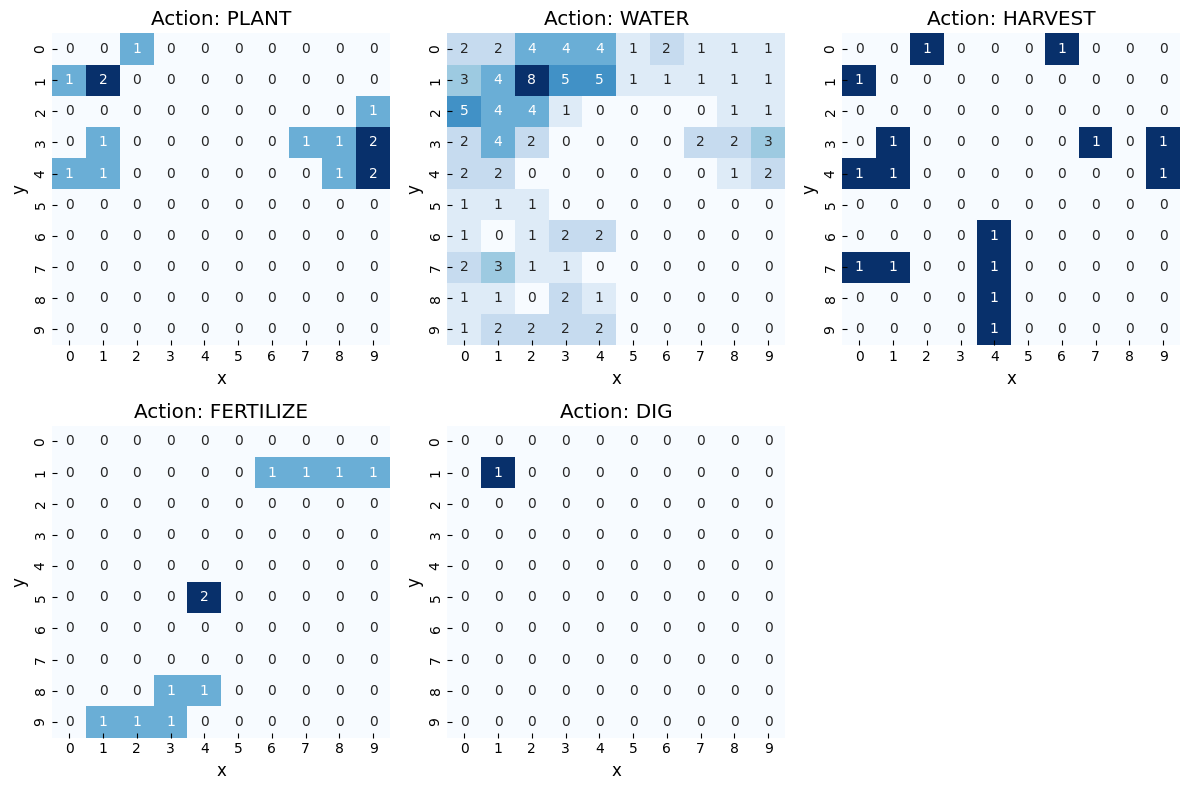

従業員7


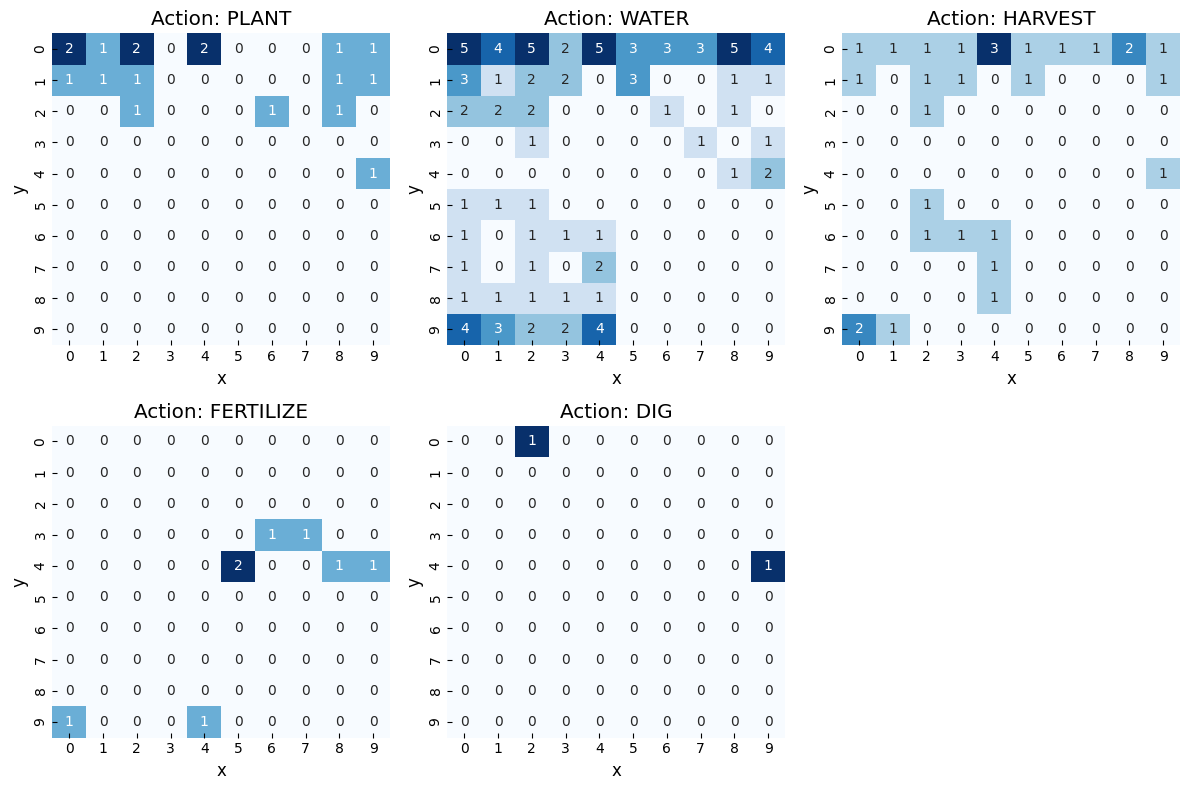

従業員8


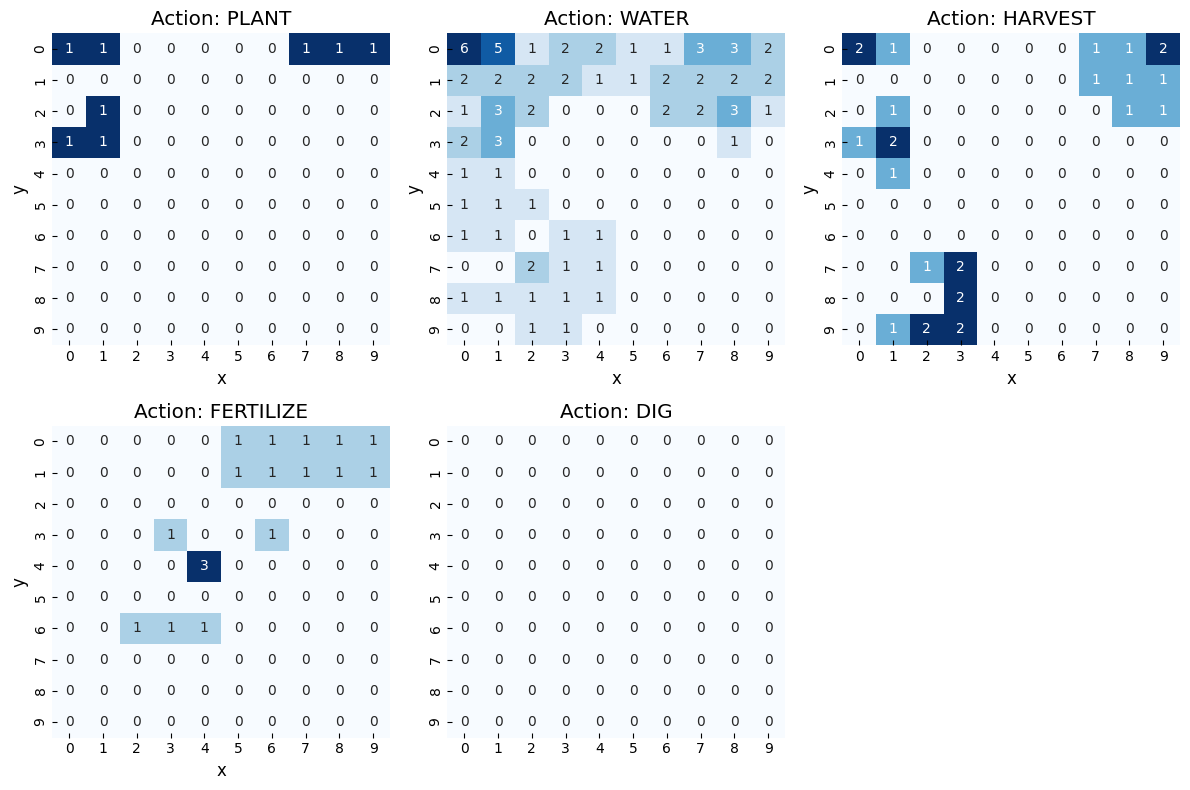

従業員9


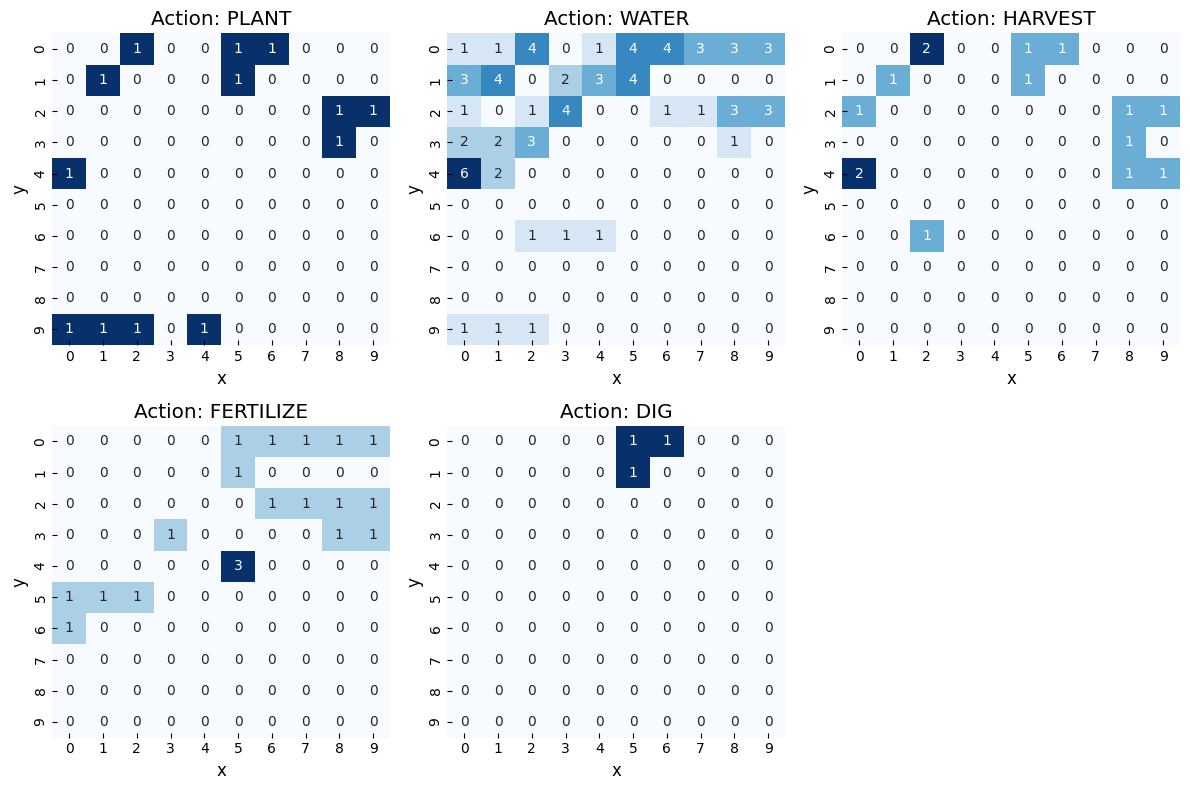

従業員10


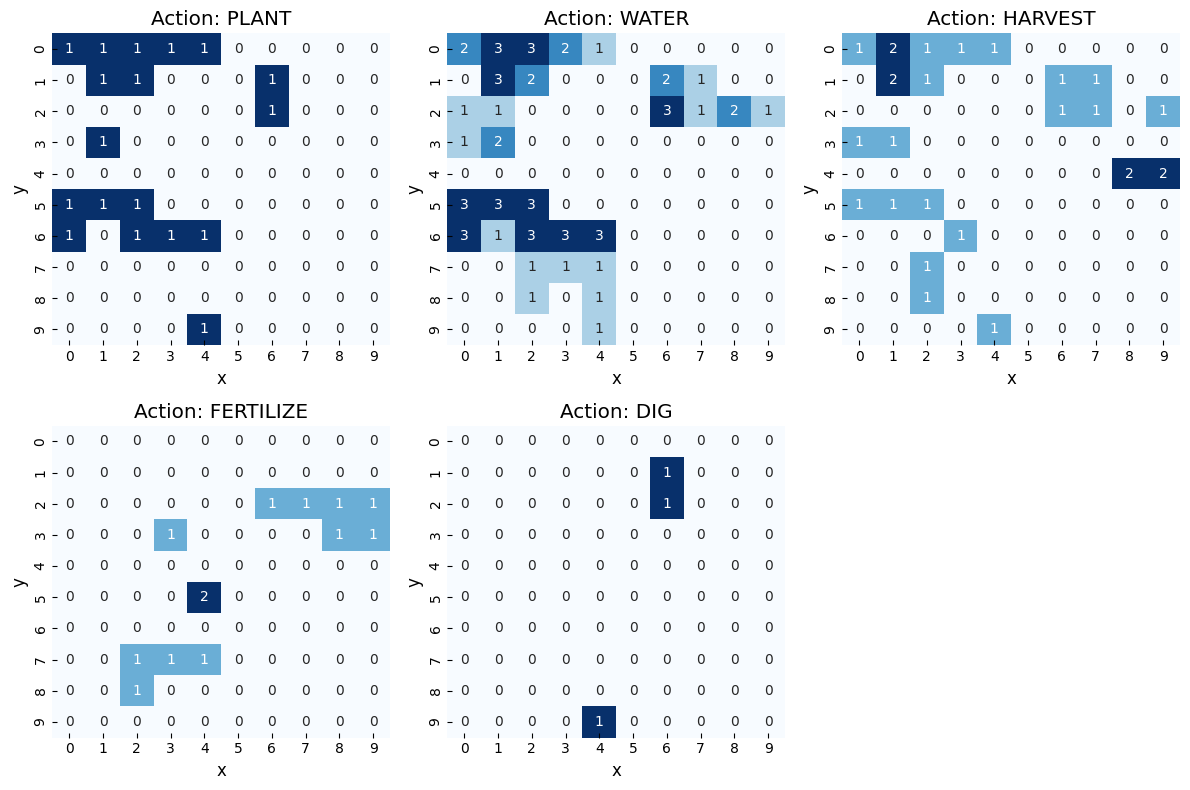

従業員11


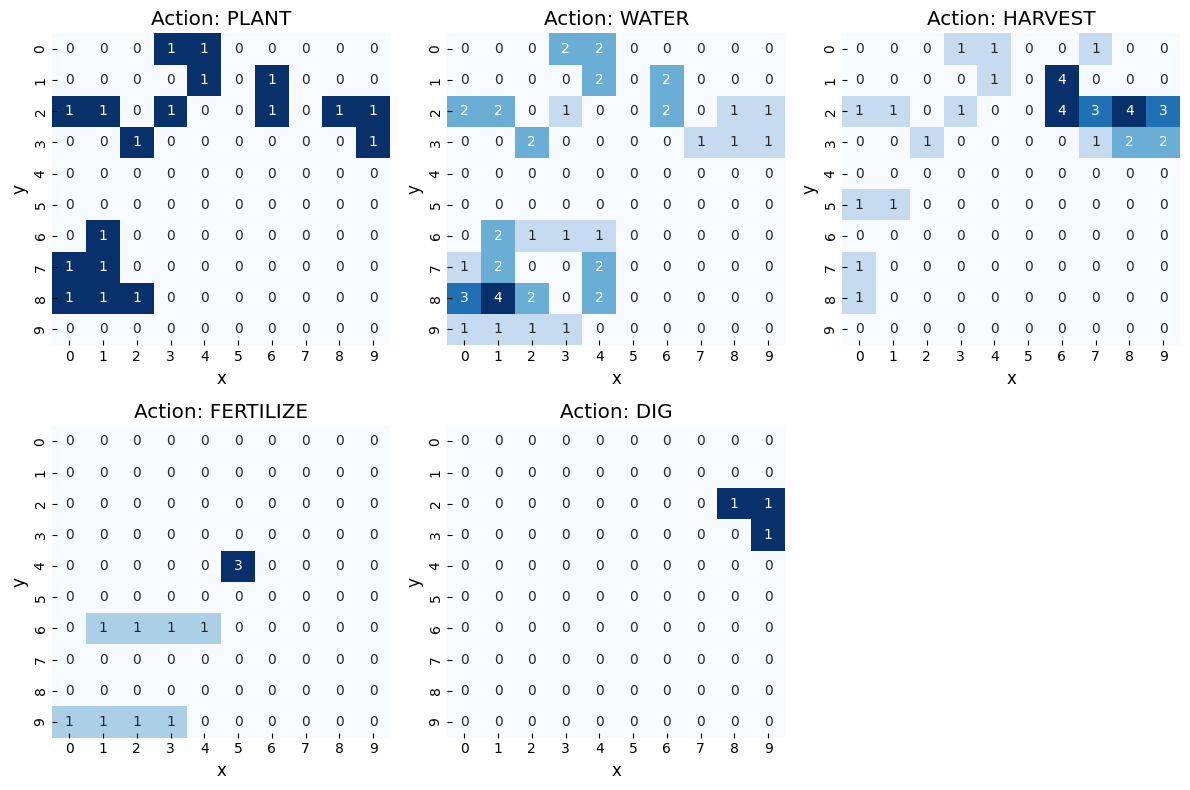

従業員12


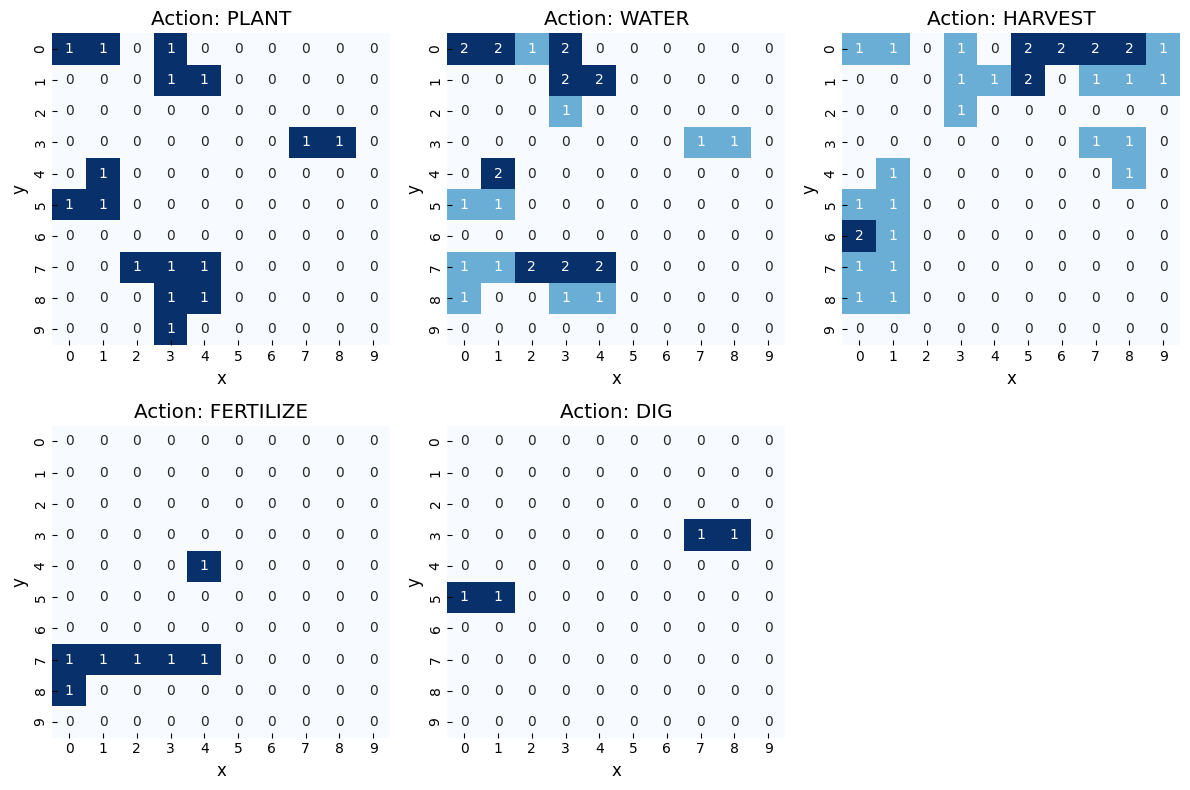

従業員13


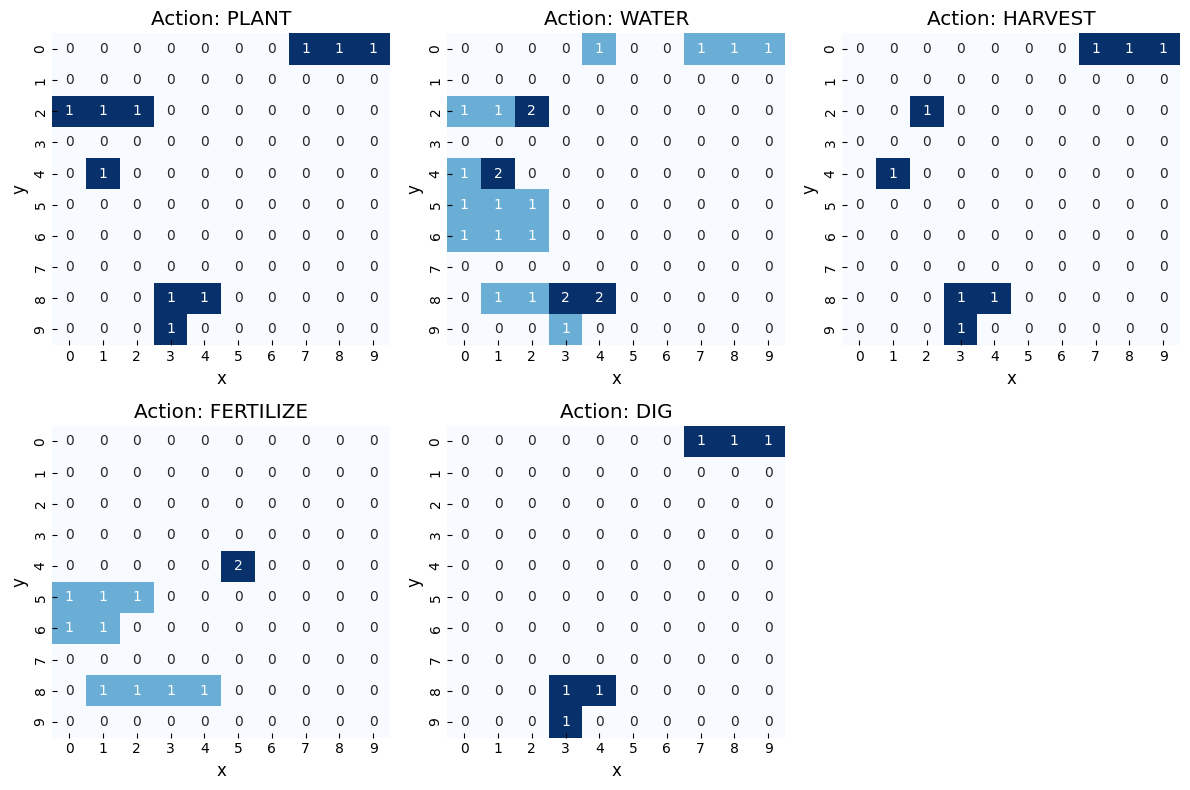

従業員14


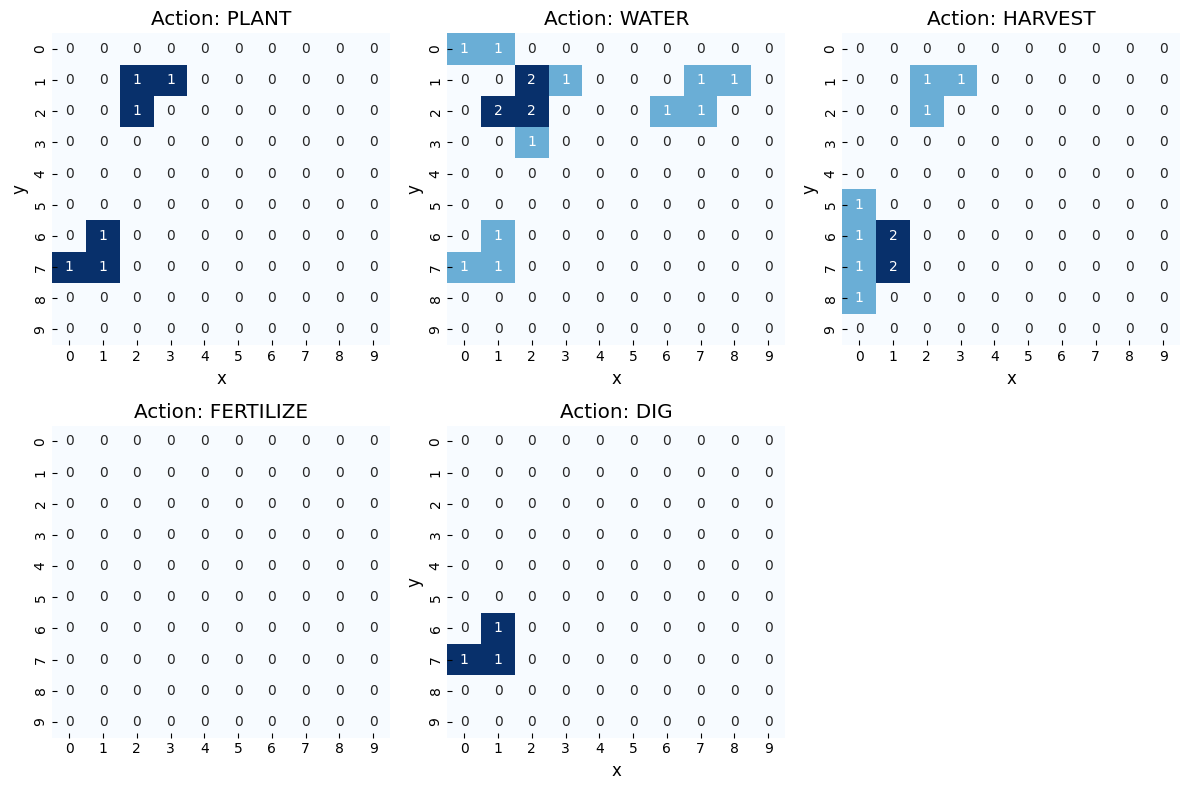

In [ ]:
def ac_agriculture(num):
    print(f"従業員{num}")
    target_list = ["PLANT", "WATER", "HARVEST","FERTILIZE","DIG" ]
    my_action_2d_plt_all(df_st[f'hands_list_{num}'], df_st[f'hands_action_list_{num}'], target_list, 2, 3)

for i in range(1, 15):
    ac_agriculture(i)

## 畜産（動物）

```
BUILD_COOP: 鳥小屋（Gooseなどの鳥用）を建設します。

BUILD_PASTURE: 牧草地（牛や羊用）を建設します。

FEED: 手持ちの作物（小麦など）を消費して、動物にエサを与えます（1日1回）

COLLECT_FERTILIZER:動物から排出された肥料（FERTILIZER）を回収します。動物1頭につき1日1つ生成されます。

CARE:動物の世話をします（1日1回）
```

* 農家

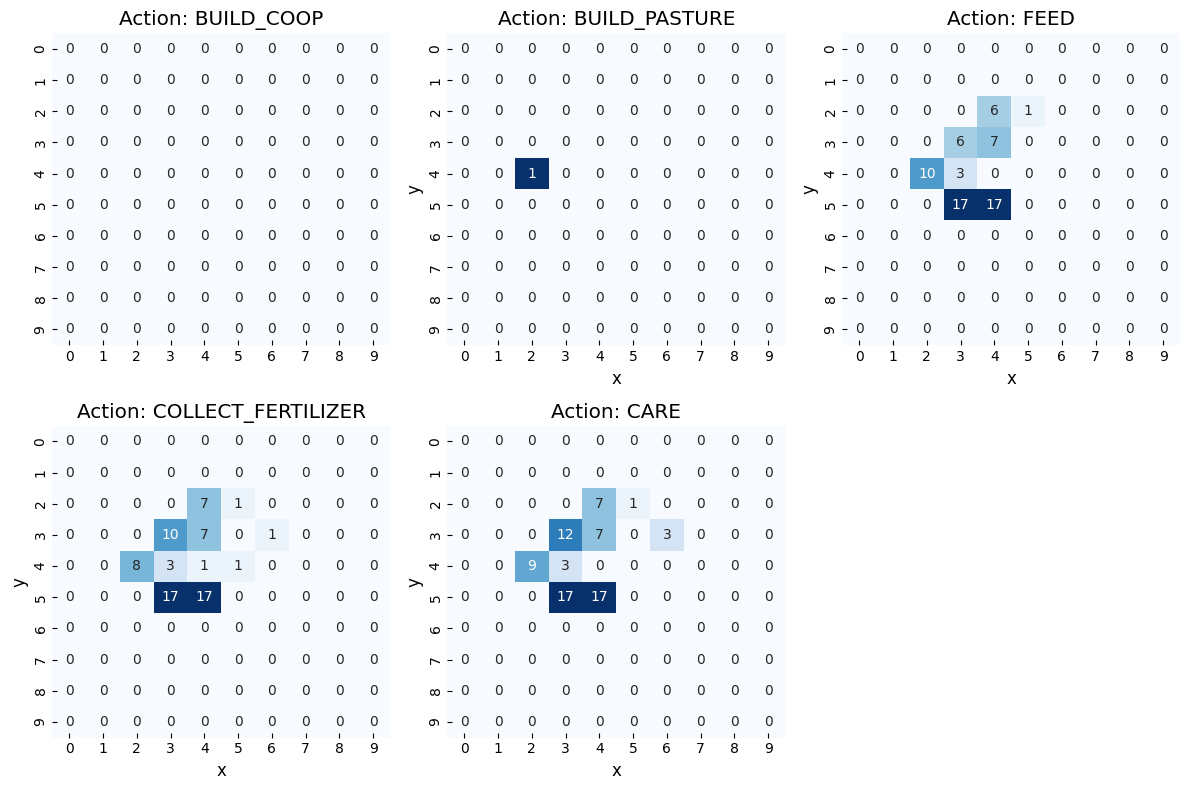

In [ ]:
target_list = ["BUILD_COOP", "BUILD_PASTURE", "FEED","COLLECT_FERTILIZER","CARE" ]
my_action_2d_plt_all(df_st_action["farmer_x_y"], df_st_action["farmer_action"], target_list, 2, 3)

従業員1


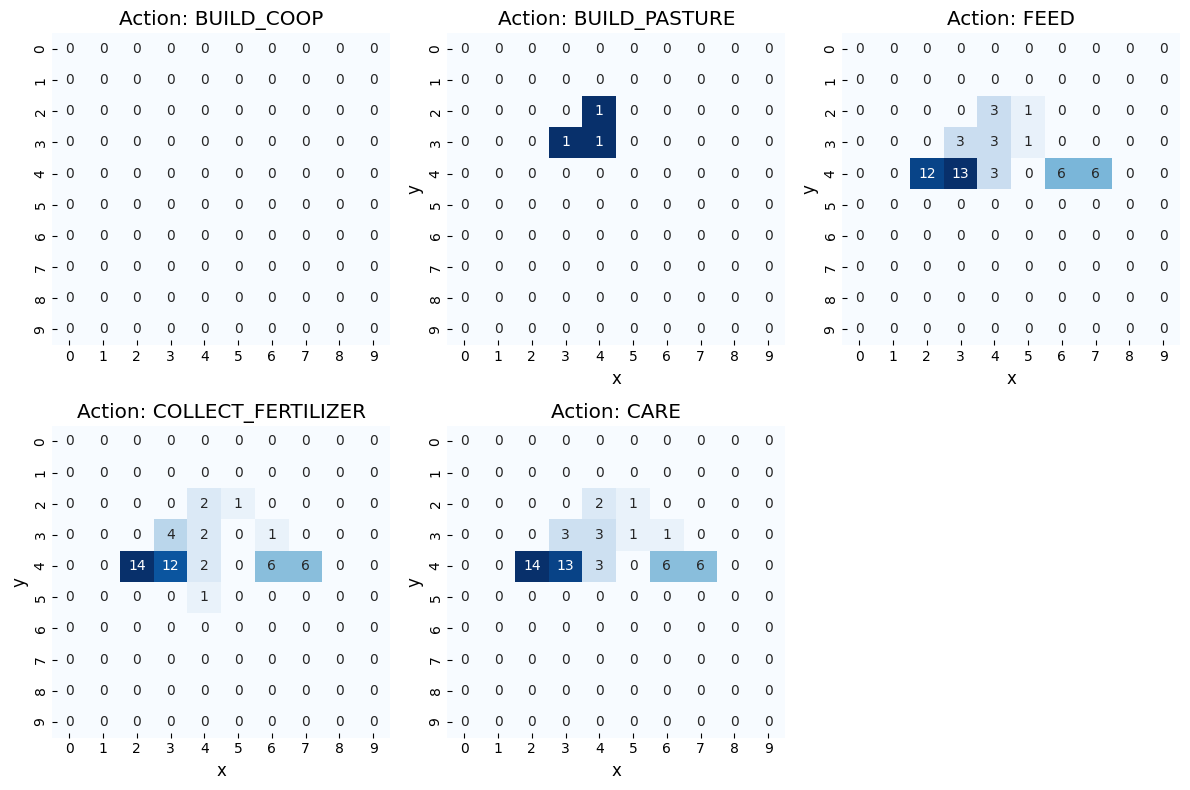

従業員2


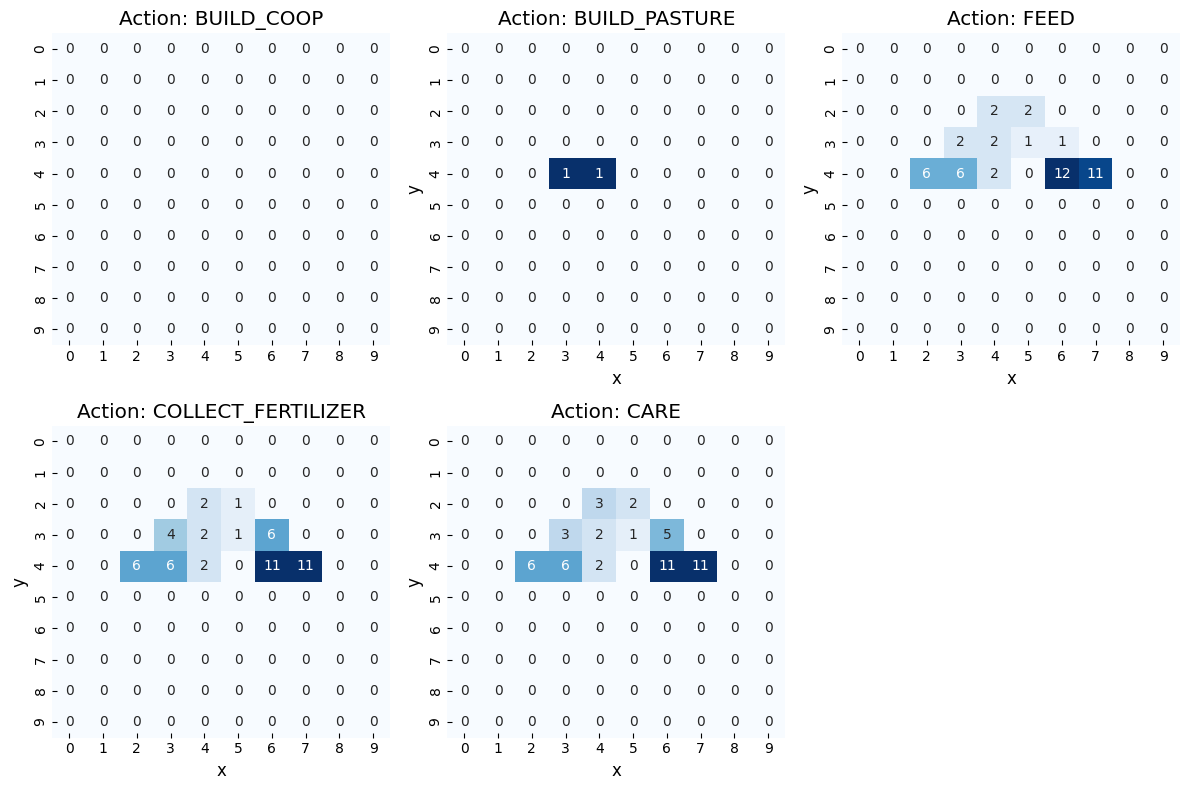

従業員3


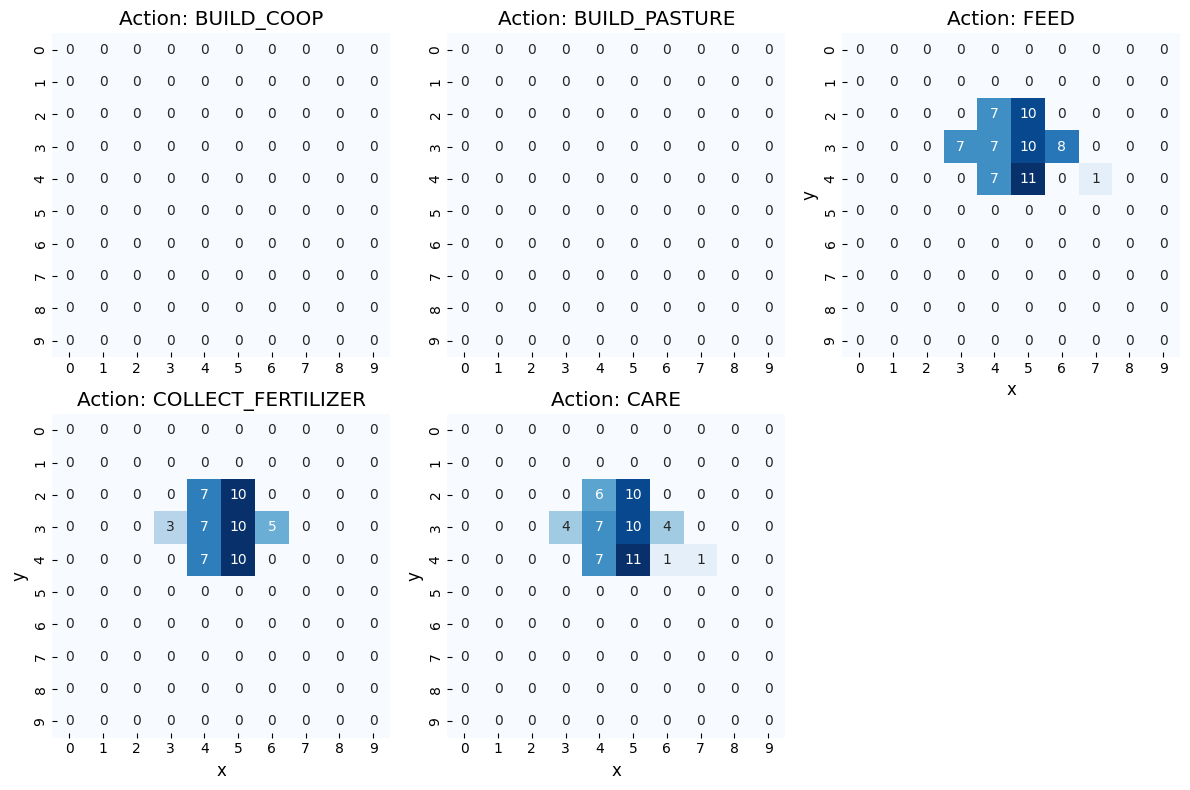

従業員4


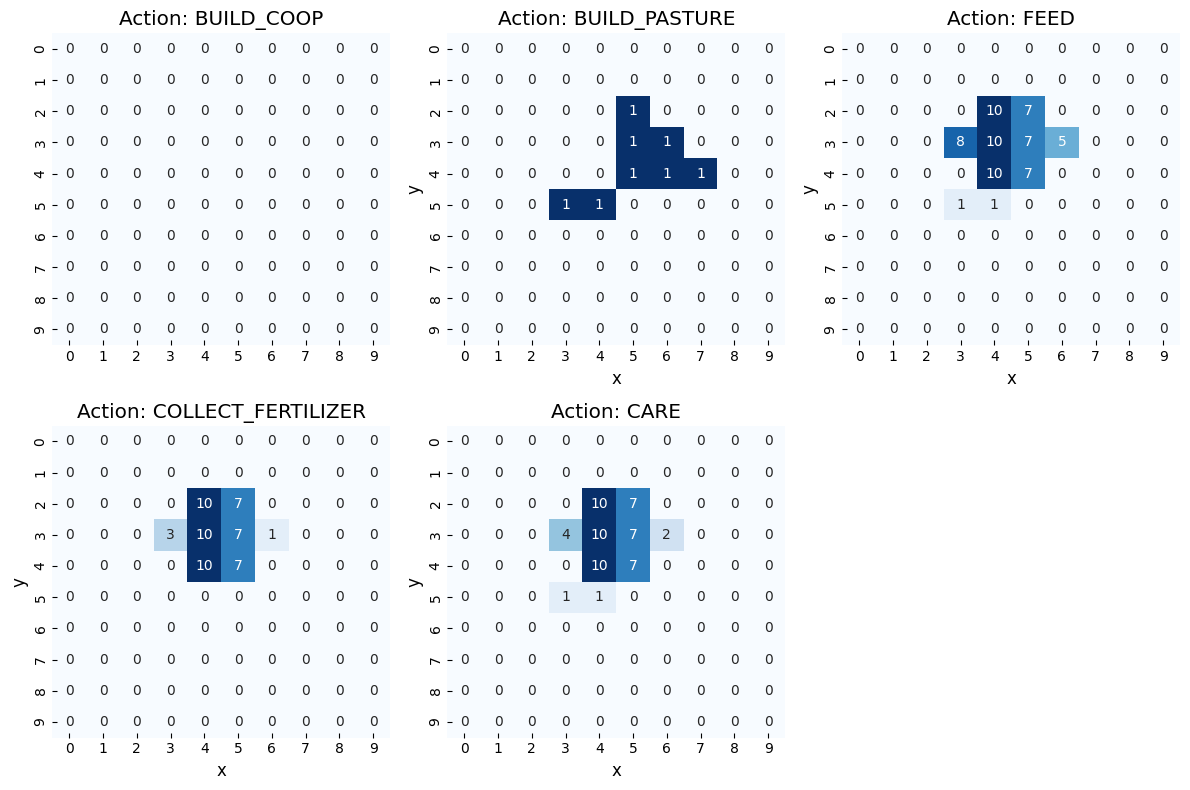

従業員5


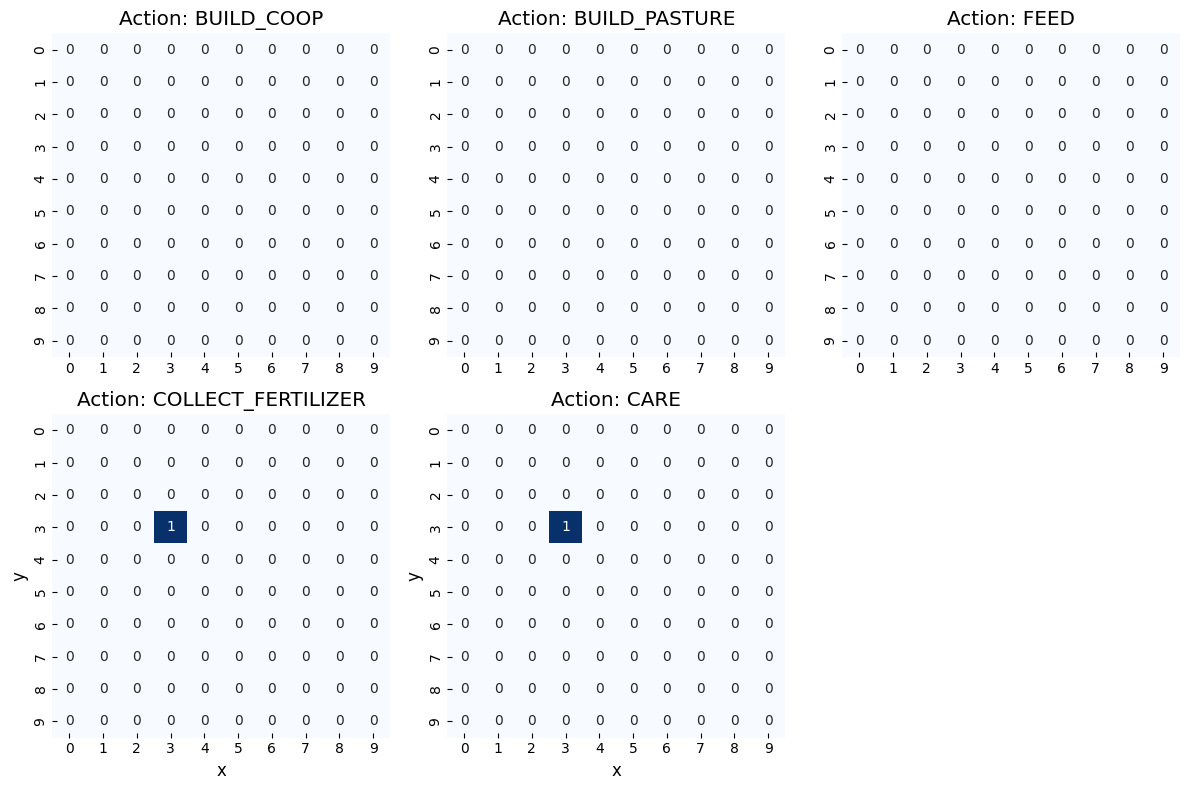

従業員6


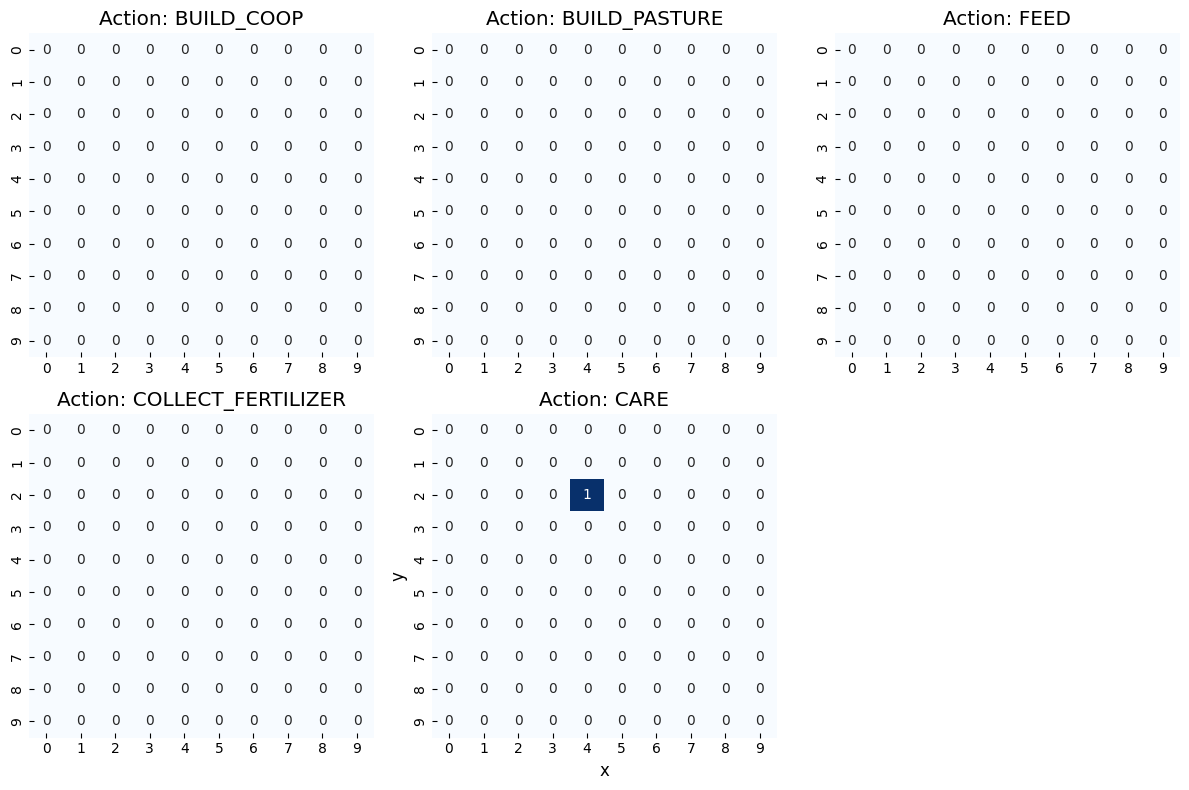

従業員7


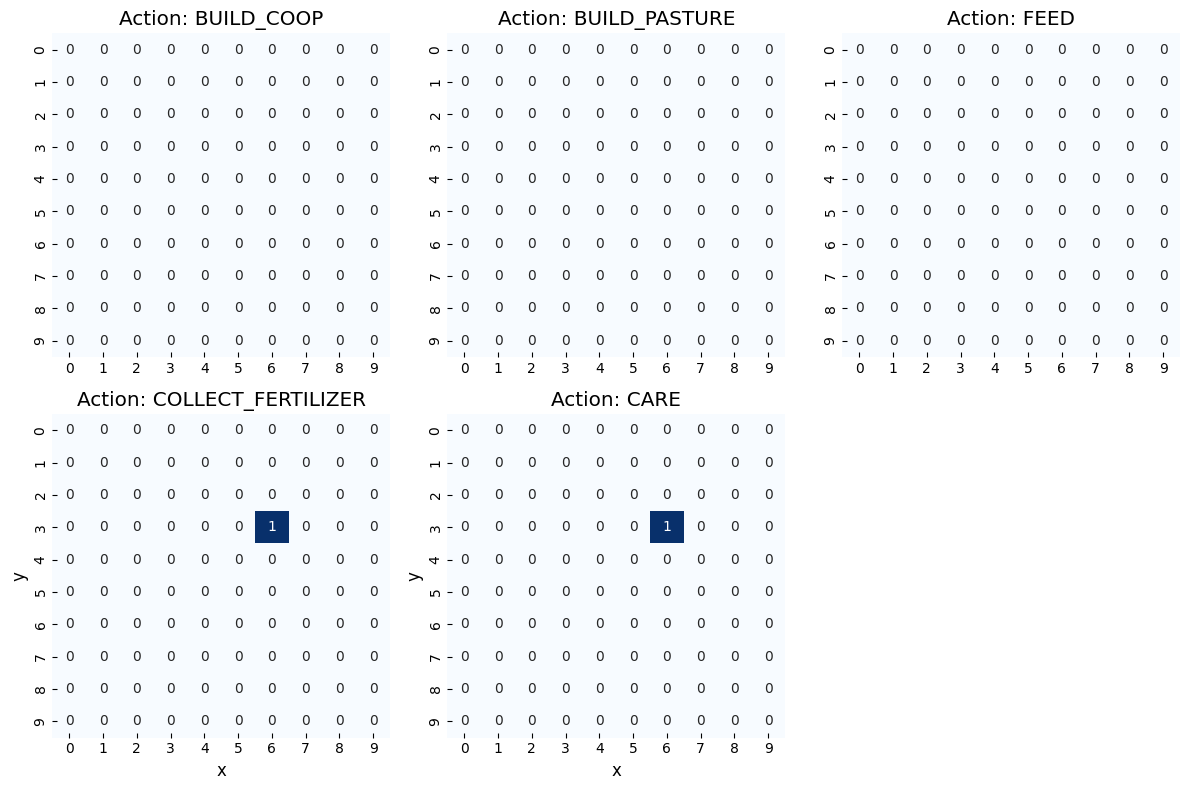

従業員8


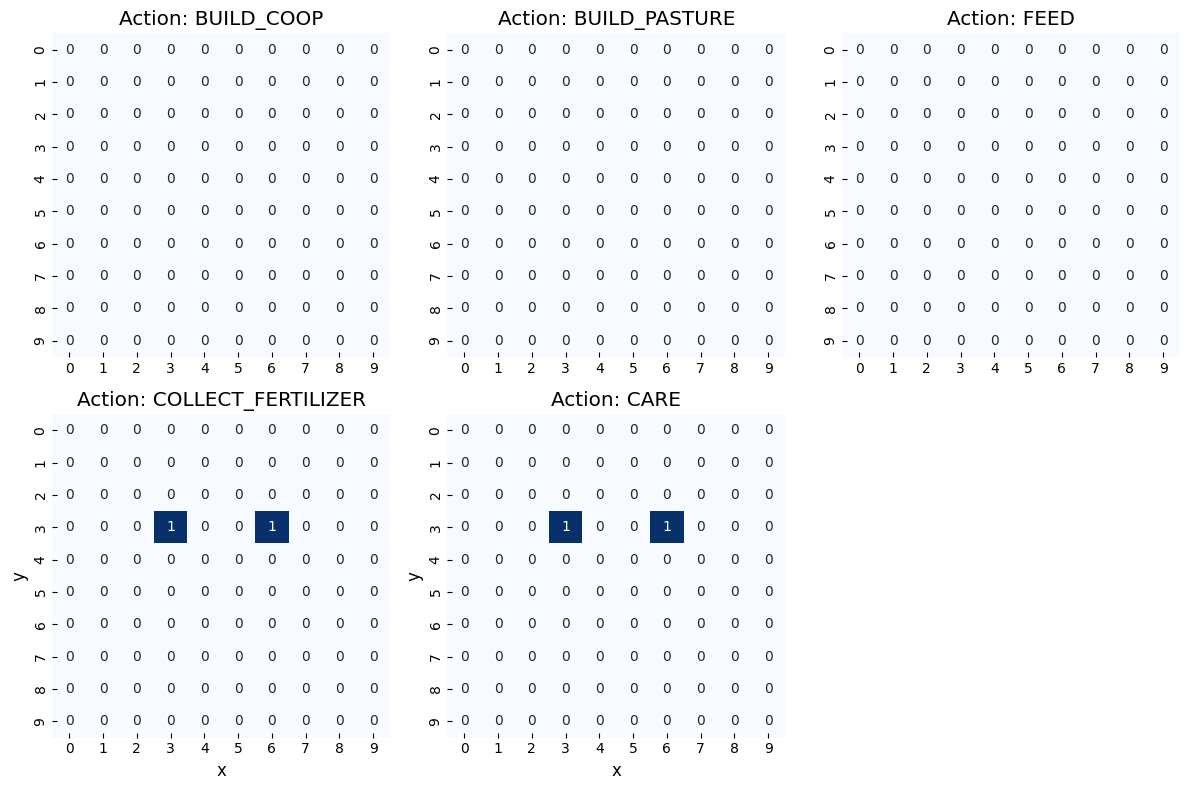

従業員9


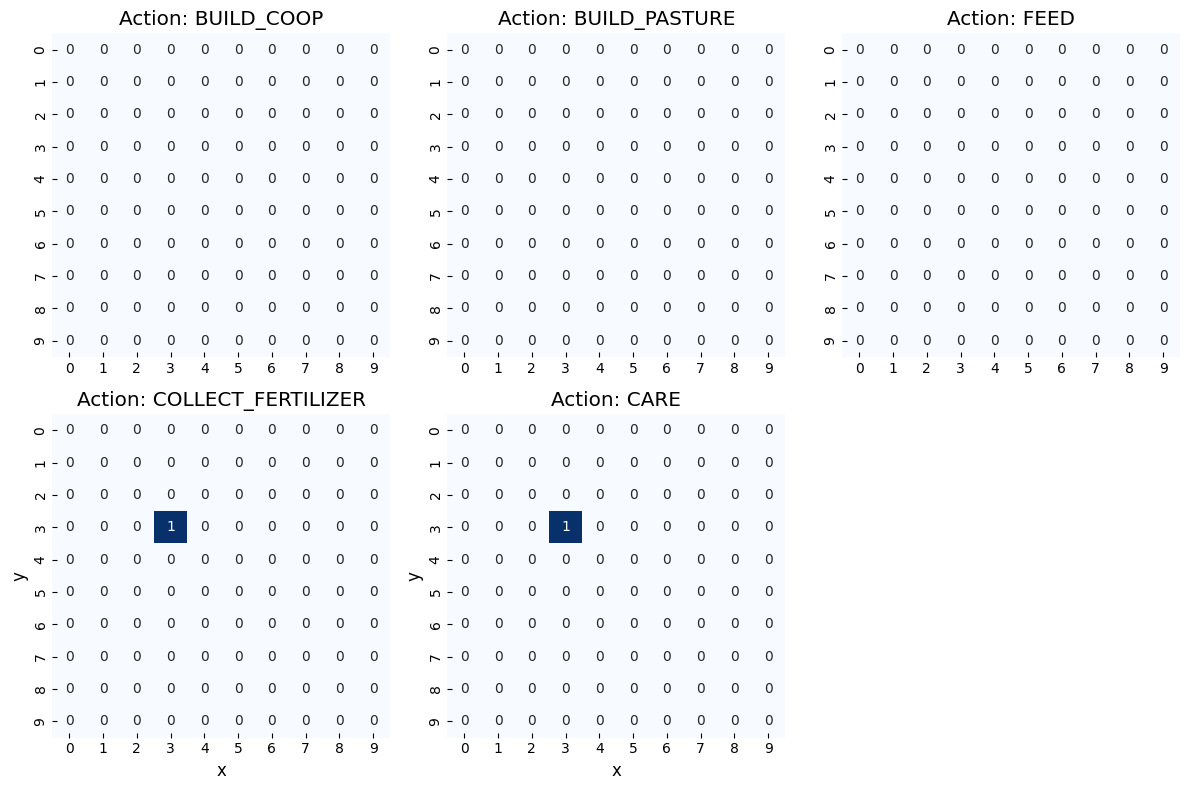

従業員10


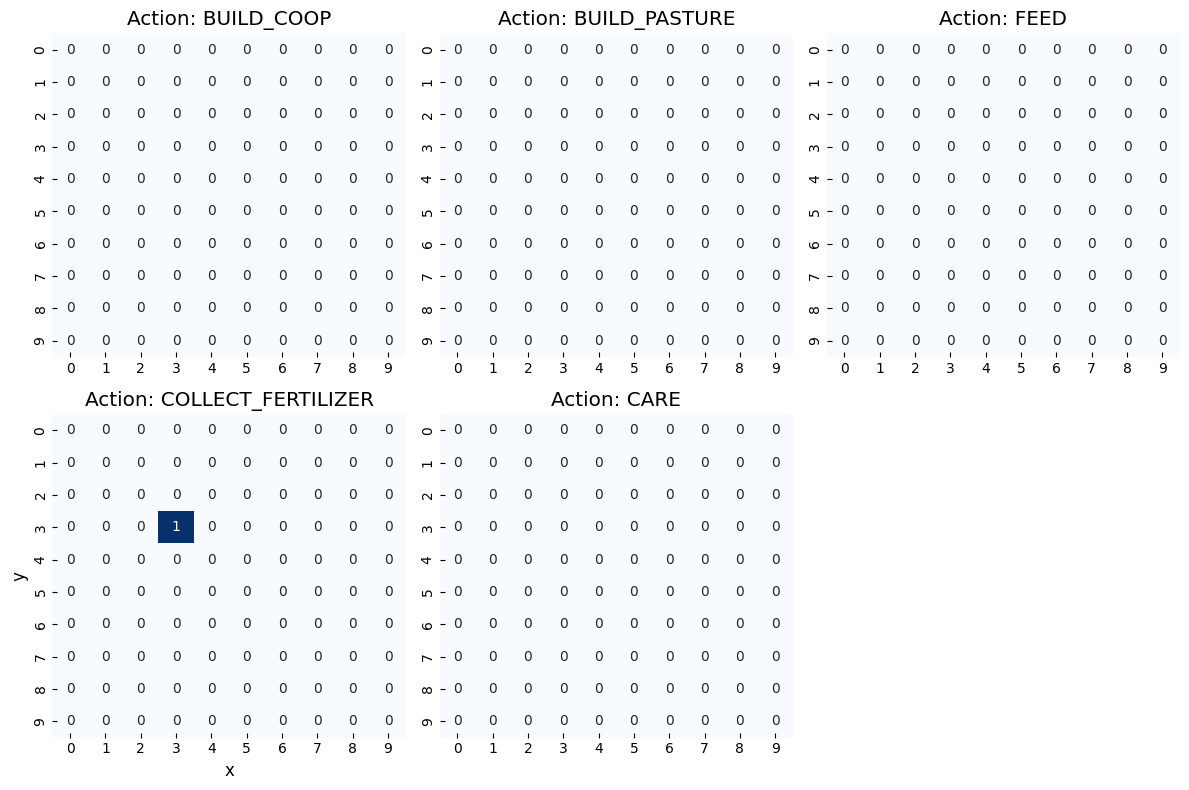

従業員11


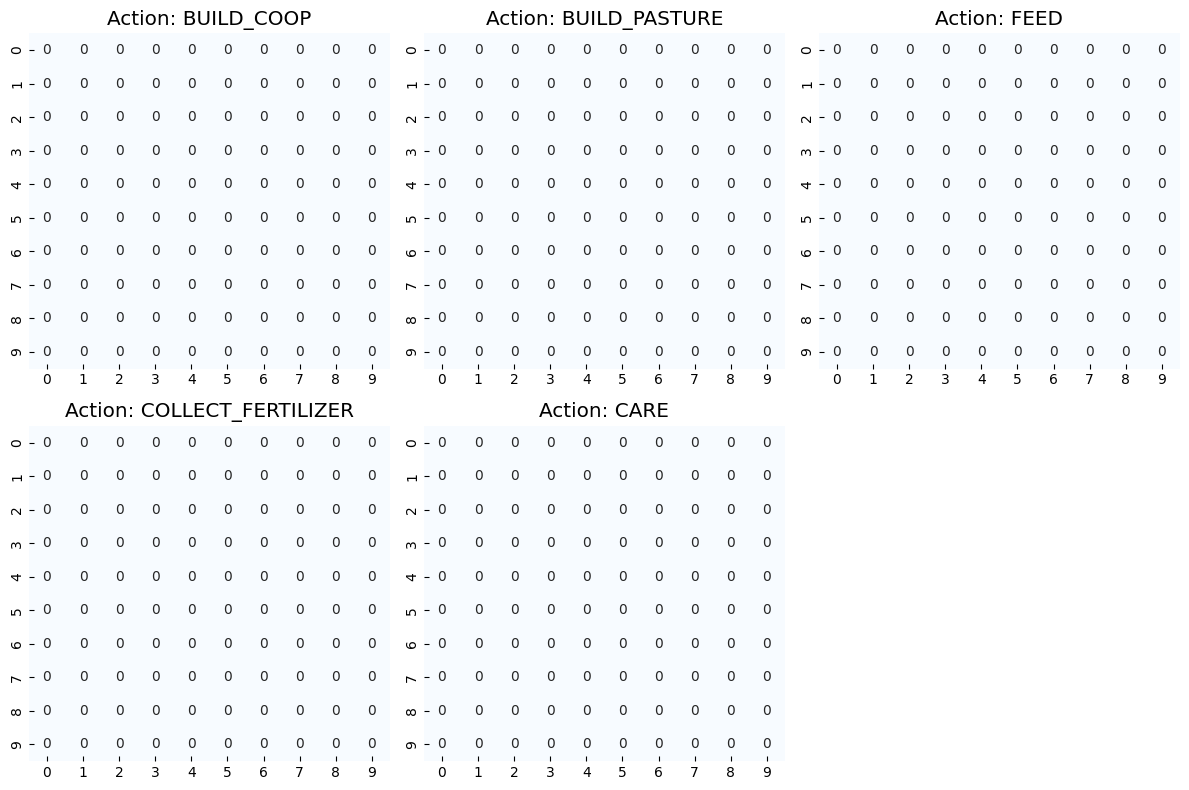

従業員12


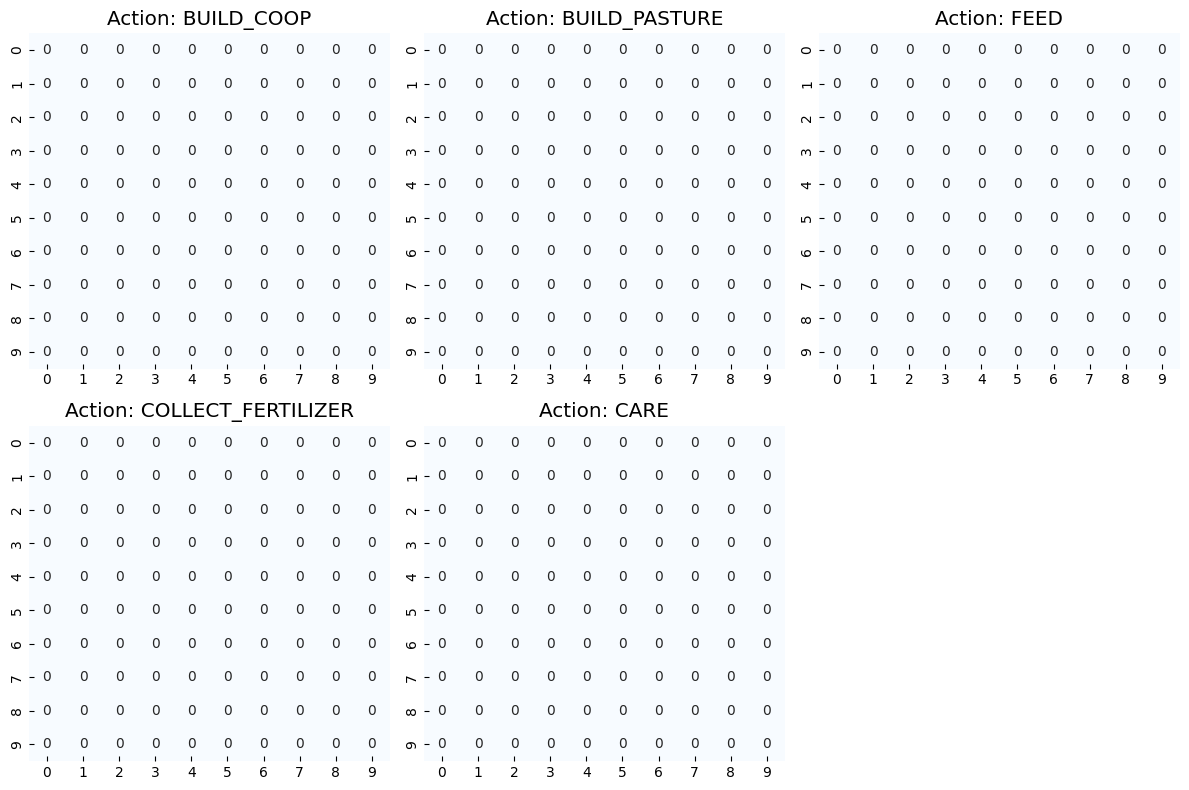

従業員13


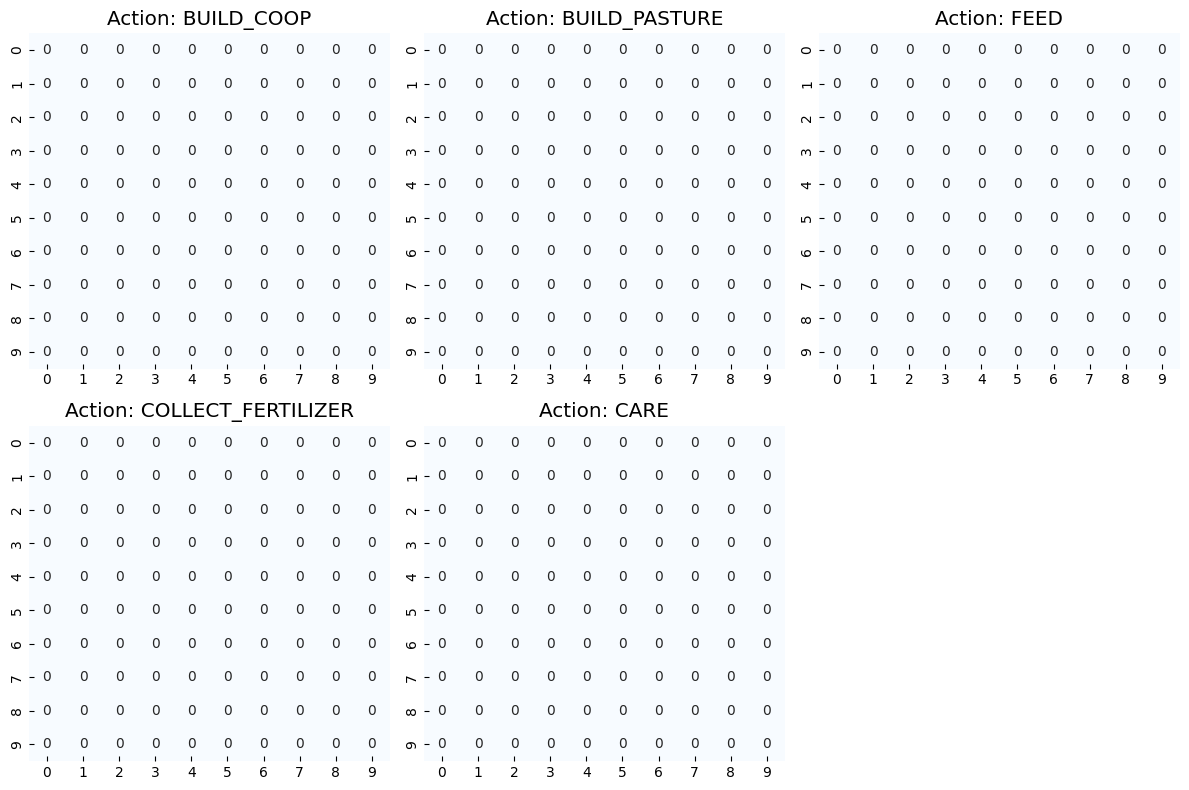

従業員14


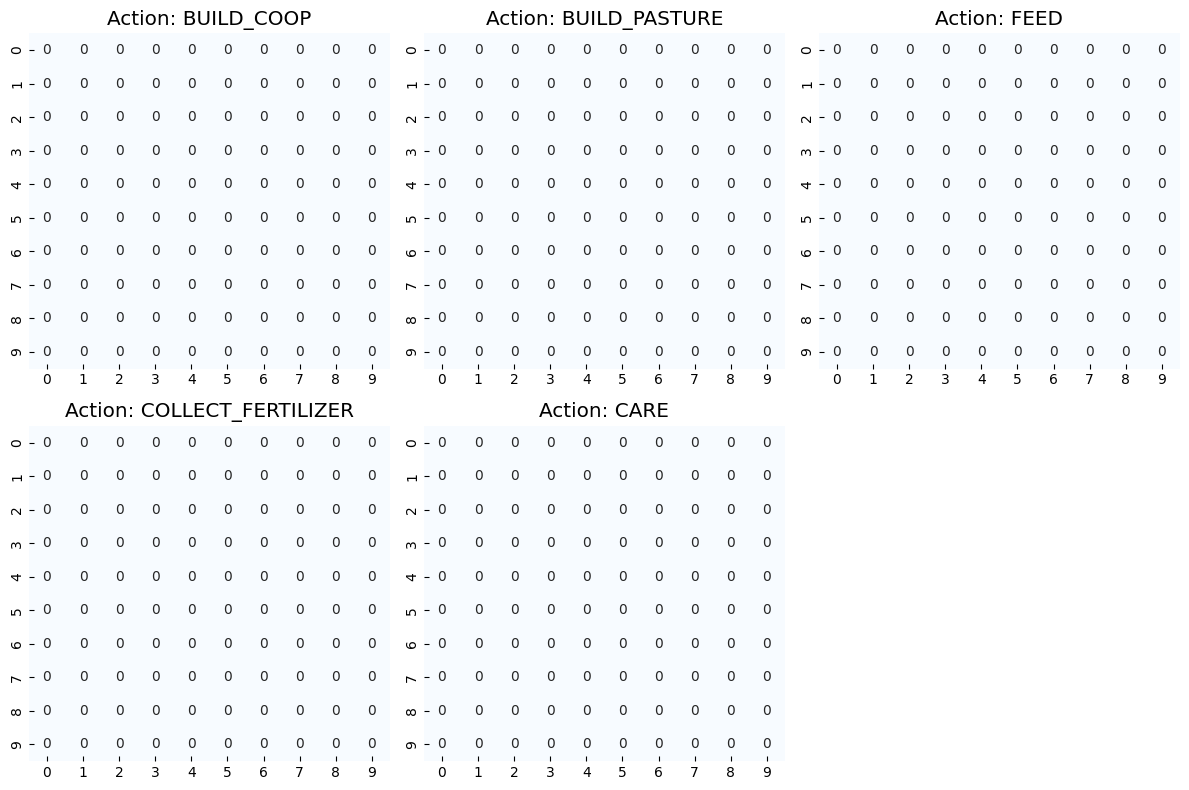

In [ ]:
def ac_animal(num):
    print(f"従業員{num}")
    target_list = ["BUILD_COOP", "BUILD_PASTURE", "FEED","COLLECT_FERTILIZER","CARE" ]
    my_action_2d_plt_all(df_st[f'hands_list_{num}'], df_st[f'hands_action_list_{num}'], target_list, 2, 3)

for i in range(1, 15):
    ac_animal(i)

# 4.それぞれの役割まとめ

|||
|---|---|
|NW|NE|
|SW|SE|






### 農家

|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|肥料をまく|NS|農業(植物)|`FERTILIZE`|
|餌やり|NS|畜産（動物）|`FEED`|
|肥料回収|NS|畜産（動物）|`COLLECT_FERTILIZER`|
|動物の世話|NS|畜産（動物）|`CARE`|

### 従業員1
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW|農業(植物)|`WATER`|
|餌やり|WN,NE|畜産（動物）|`FEED`|
|肥料回収|WN,NE|畜産（動物）|`COLLECT_FERTILIZER`|
|肥料をまく|[4,4][6,4]付近||`FERTILIZE`|

### 従業員2
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW|農業(植物)|`WATER`|
|植物回収|NE|農業(植物)|`HARVEST`|
|肥料をまく|NE|農業(植物)|`FERTILIZE`|
|餌やり|NE|畜産（動物）|`FEED`|
|肥料回収|NE|畜産（動物）|`COLLECT_FERTILIZER`|
|動物の世話|NE|畜産（動物）|`CARE`|

### 従業員3
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW|農業(植物)|`WATER`|
|餌やり|NW,NE|畜産（動物）|`FEED`|
|肥料回収|NE|畜産（動物）|`COLLECT_FERTILIZER`|
|動物の世話|NE|畜産（動物）|`CARE`|
|植物回収|NE|農業(植物)|`HARVEST`|

### 従業員4
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW|農業(植物)|`WATER`|
|種を植える|NW|農業(植物)|`PLANT`|
|植物回収|中心部|農業(植物)|`HARVEST`|
|牧草地建設|中心部|畜産（動物）|`BUILD_PASTURE`|
|肥料をまく|中心部|農業(植物)|`FERTILIZE`|
|動物の世話|中心部|畜産（動物）|`CARE`|
|餌やり|中心部|畜産（動物）|`FEED`|
|肥料回収|中心部|畜産（動物）|`COLLECT_FERTILIZER`|

### 従業員5
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW,NE|農業(植物)|`WATER`|
|植物回収|NW|農業(植物)|`HARVEST`|

### 従業員6
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW,NE,SW|農業(植物)|`WATER`|

### 従業員7
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW,NE,SW|農業(植物)|`WATER`|

### 従業員8
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW,NE,SW|農業(植物)|`WATER`|
|植物回収|SW|農業(植物)|`HARVEST`|

### 従業員9
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW|農業(植物)|`WATER`|

### 従業員10
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|NW,SW,NE|農業(植物)|`WATER`|
|植物回収|NW|農業(植物)|`HARVEST`|
|種を植える|SW|農業(植物)|`PLANT`|

### 従業員11
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|種を植える|NW,SW|農業(植物)|`PLANT`|
|植物回収|NE|農業(植物)|`HARVEST`|
|水やり|SW|農業(植物)|`WATER`|

### 従業員12
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|植物回収|NE|農業(植物)|`HARVEST`|

### 従業員13
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|SW|農業(植物)|`WATER`|
|肥料をまく|SW|農業(植物)|`FERTILIZE`|

### 従業員14
|行動|行動範囲|種目|コマンド|
|-----|-----|-----|-----|
|水やり|SW|農業(植物)|`WATER`|
|肥料をまく|SW|農業(植物)|`FERTILIZE`|